# Integrated Mixed Precision Training Analysis

This comprehensive notebook analyzes mixed precision training performance across different hardware platforms, models, and precision formats. The analysis integrates data from training experiments, inference benchmarks, and performance metrics to provide insights for the thesis Results section.

## Experiment Overview
- **Hardware Platforms**: NVIDIA RTX 4090, NVIDIA L40S, AMD RX 7900 XT
- **Models**: BERT-large, GPT-2, ResNet-50
- **Precision Formats**: FP32 (baseline), FP16, BF16
- **Metrics**: Throughput, Power Consumption, Memory Usage, GPU Utilization

In [57]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import glob
from pathlib import Path
import warnings
from scipy import stats
from collections import defaultdict

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
warnings.filterwarnings('ignore')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully")
print("✓ Plotting configuration set")
print("✓ Ready for mixed precision analysis")

✓ Libraries imported successfully
✓ Plotting configuration set
✓ Ready for mixed precision analysis


## 1. Data Loading and Parsing Functions

Define comprehensive functions to load and parse experimental data from various sources including training experiments, inference benchmarks, and raw performance metrics.

In [58]:
def parse_json_stream(file_path):
    """Parse a file containing concatenated JSON objects (from inference metrics)."""
    objects = []
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        
        decoder = json.JSONDecoder()
        pos = 0
        
        # Skip leading whitespace
        while pos < len(content) and content[pos].isspace():
            pos += 1
        
        while pos < len(content):
            try:
                obj, pos = decoder.raw_decode(content, pos)
                objects.append(obj)
                # Skip whitespace between objects
                while pos < len(content) and content[pos].isspace():
                    pos += 1
            except json.JSONDecodeError:
                break
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
    
    return objects

def load_training_metrics(base_dir='train_exp_results'):
    """Load training epoch metrics from JSON files."""
    metrics_dir = os.path.join(base_dir, 'epoch_metrics')
    
    if not os.path.exists(metrics_dir):
        print(f"Training metrics directory not found: {metrics_dir}")
        return pd.DataFrame()
    
    json_files = glob.glob(os.path.join(metrics_dir, '*.json'))
    all_metrics = []
    
    for file_path in json_files:
        try:
            with open(file_path, 'r') as f:
                for line in f:
                    if line.strip():
                        # Replace single quotes with double quotes
                        valid_json_string = line.replace("'", '"')
                        try:
                            data = json.loads(valid_json_string)
                            all_metrics.append(data)
                        except json.JSONDecodeError as e:
                            continue
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    
    if all_metrics:
        df = pd.DataFrame(all_metrics)
        print(f"✓ Loaded {len(df)} training metric records from {len(json_files)} files")
        return df
    else:
        print("No training metrics loaded")
        return pd.DataFrame()

def load_inference_metrics(base_dir='infer_metrics/infer_metrics'):
    """Load inference metrics from JSON stream files."""
    if not os.path.exists(base_dir):
        print(f"Inference metrics directory not found: {base_dir}")
        return pd.DataFrame()
    
    json_files = glob.glob(os.path.join(base_dir, '*.json'))
    all_metrics = []
    
    for file_path in json_files:
        metrics_from_file = parse_json_stream(file_path)
        all_metrics.extend(metrics_from_file)
    
    if all_metrics:
        df = pd.DataFrame(all_metrics)
        if 'experiment_num' in df.columns:
            df = df.sort_values(by='experiment_num').reset_index(drop=True)
        print(f"✓ Loaded {len(df)} inference metric records from {len(json_files)} files")
        return df
    else:
        print("No inference metrics loaded")
        return pd.DataFrame()

def load_precision_batch_results(gpu_dirs=['4090', '7900', 'grace']):
    """Load precision and batch size experiment results."""
    all_results = []
    
    for gpu_dir in gpu_dirs:
        # Map directory names to GPU names
        gpu_name_map = {
            '4090': 'NVIDIA GeForce RTX 4090',
            '7900': 'Radeon RX 7900 XT',
            'grace': 'NVIDIA L40S'
        }
        
        gpu_name = gpu_name_map.get(gpu_dir, gpu_dir)
        results_dir = os.path.join('train_experiment_data', gpu_dir, 'results_precision_batch')
        
        if not os.path.exists(results_dir):
            print(f"Directory not found: {results_dir}")
            continue
        
        csv_files = glob.glob(os.path.join(results_dir, '*.csv'))
        
        for file_path in csv_files:
            filename = os.path.basename(file_path)
            
            # Skip raw metrics files for main analysis
            if 'raw_metrics' in filename:
                continue
                
            try:
                df = pd.read_csv(file_path)
                df['gpu'] = gpu_name
                df['gpu_dir'] = gpu_dir
                all_results.append(df)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    
    if all_results:
        combined_df = pd.concat(all_results, ignore_index=True)
        print(f"✓ Loaded precision/batch results: {len(combined_df)} records from {len(gpu_dirs)} GPUs")
        return combined_df
    else:
        print("No precision/batch results loaded")
        return pd.DataFrame()

def load_inference_batch_results(gpu_dirs=['4090', '7900', 'grace']):
    """Load inference batch size experiment results."""
    all_results = []
    
    for gpu_dir in gpu_dirs:
        gpu_name_map = {
            '4090': 'NVIDIA GeForce RTX 4090',
            '7900': 'Radeon RX 7900 XT', 
            'grace': 'NVIDIA L40S'
        }
        
        gpu_name = gpu_name_map.get(gpu_dir, gpu_dir)
        results_dir = os.path.join('train_experiment_data', gpu_dir, 'results_inference_batch')
        
        if not os.path.exists(results_dir):
            print(f"Directory not found: {results_dir}")
            continue
            
        summary_file = os.path.join(results_dir, 'summary.csv')
        
        if os.path.exists(summary_file):
            try:
                df = pd.read_csv(summary_file)
                df['gpu'] = gpu_name
                df['gpu_dir'] = gpu_dir
                all_results.append(df)
            except Exception as e:
                print(f"Error reading {summary_file}: {e}")
    
    if all_results:
        combined_df = pd.concat(all_results, ignore_index=True)
        print(f"✓ Loaded inference batch results: {len(combined_df)} records")
        return combined_df
    else:
        print("No inference batch results loaded")
        return pd.DataFrame()

print("✓ Data loading functions defined")
print("Available functions:")
print("  - parse_json_stream(): Parse concatenated JSON files")
print("  - load_training_metrics(): Load training epoch metrics") 
print("  - load_inference_metrics(): Load inference performance data")
print("  - load_precision_batch_results(): Load precision/batch experiments")
print("  - load_inference_batch_results(): Load inference batch experiments")

✓ Data loading functions defined
Available functions:
  - parse_json_stream(): Parse concatenated JSON files
  - load_training_metrics(): Load training epoch metrics
  - load_inference_metrics(): Load inference performance data
  - load_precision_batch_results(): Load precision/batch experiments
  - load_inference_batch_results(): Load inference batch experiments


In [59]:
# Load all experimental data
print("Loading experimental datasets...")
print("=" * 50)

# Load training metrics
training_df = load_training_metrics()

# Load inference metrics  
inference_df = load_inference_metrics()

# Load precision/batch experiments
precision_batch_df = load_precision_batch_results()

# Load inference batch experiments
inference_batch_df = load_inference_batch_results()

print("\n" + "=" * 50)
print("Data Loading Summary:")
print(f"Training metrics: {len(training_df)} records")
print(f"Inference metrics: {len(inference_df)} records") 
print(f"Precision/batch experiments: {len(precision_batch_df)} records")
print(f"Inference batch experiments: {len(inference_batch_df)} records")

# Display sample data structure
if not training_df.empty:
    print(f"\nTraining data columns: {list(training_df.columns)}")
if not inference_df.empty:
    print(f"Inference data columns: {list(inference_df.columns)}")
if not precision_batch_df.empty:
    print(f"Precision/batch data columns: {list(precision_batch_df.columns)}")
if not inference_batch_df.empty:
    print(f"Inference batch data columns: {list(inference_batch_df.columns)}")

Loading experimental datasets...
✓ Loaded 26381 training metric records from 28 files
✓ Loaded 4466 inference metric records from 27 files
✓ Loaded 26381 training metric records from 28 files
✓ Loaded 4466 inference metric records from 27 files
✓ Loaded precision/batch results: 352 records from 3 GPUs
✓ Loaded inference batch results: 486 records

Data Loading Summary:
Training metrics: 26381 records
Inference metrics: 4466 records
Precision/batch experiments: 352 records
Inference batch experiments: 486 records

Training data columns: ['experiment_num', 'gpu_vendor', 'gpu_name', 'model', 'precision', 'batch_size', 'epoch', 'loss', 'epoch_time_sec', 'samples', 'samples_per_sec', 'nan_inf_count_so_far', 'skipped_steps_so_far', 'mem_alloc_bytes', 'mem_reserved_bytes', 'max_mem_alloc_bytes', 'max_mem_reserved_bytes', 'gpu_util_percent', 'mem_util_percent', 'power_watts']
Inference data columns: ['model', 'precision', 'pretrained', 'device', 'batch_size', 'num_batches', 'warmup_batches', '

## 2. Training Performance Analysis

Analyze training throughput across different models, precision formats, and GPU platforms. Focus on stable performance metrics by filtering out warm-up epochs.

In [60]:
def analyze_training_performance(training_df):
    """Analyze training performance with stable epoch filtering."""
    
    if training_df.empty:
        print("No training data available for analysis")
        return None
    
    # Filter out warm-up epochs for stable analysis
    df_stable = training_df[training_df['epoch'] > 10].copy()
    
    # Calculate power efficiency
    df_stable['samples_per_watt'] = df_stable['samples_per_sec'] / (df_stable['power_watts'] + 1e-6)
    
    # Group by GPU, model, and precision for analysis
    performance_summary = df_stable.groupby(['gpu_name', 'model', 'precision']).agg(
        avg_samples_per_sec=('samples_per_sec', 'mean'),
        std_samples_per_sec=('samples_per_sec', 'std'),
        avg_power_watts=('power_watts', 'mean'),
        avg_samples_per_watt=('samples_per_watt', 'mean'),
        max_batch_size=('batch_size', 'max'),
        avg_memory_alloc_gb=('max_mem_alloc_bytes', lambda x: (x.mean() / (1024**3))),
        avg_memory_reserved_gb=('max_mem_reserved_bytes', lambda x: (x.mean() / (1024**3))),
        record_count=('epoch', 'count')
    ).round(3)
    
    return performance_summary

# Analyze training performance
if not training_df.empty:
    print("Training Performance Analysis")
    print("=" * 50)
    
    performance_summary = analyze_training_performance(training_df)
    
    if performance_summary is not None:
        print("Training Performance Summary (excluding warm-up epochs):")
        print(performance_summary)
        
        # Find best performing configurations
        print("\n" + "=" * 30)
        print("Top Performers by Throughput:")
        top_throughput = performance_summary.nlargest(5, 'avg_samples_per_sec')
        for idx, row in top_throughput.iterrows():
            gpu, model, precision = idx
            print(f"{gpu} + {model} + {precision}: {row['avg_samples_per_sec']:.1f} samples/sec")
            
        print("\n" + "=" * 30)
        print("Top Performers by Power Efficiency:")
        top_efficiency = performance_summary.nlargest(5, 'avg_samples_per_watt')
        for idx, row in top_efficiency.iterrows():
            gpu, model, precision = idx
            print(f"{gpu} + {model} + {precision}: {row['avg_samples_per_watt']:.3f} samples/watt")
    
else:
    print("No training data available for analysis")
    performance_summary = None

Training Performance Analysis
Training Performance Summary (excluding warm-up epochs):
                                              avg_samples_per_sec  std_samples_per_sec  avg_power_watts  avg_samples_per_watt  max_batch_size  avg_memory_alloc_gb  avg_memory_reserved_gb  record_count
gpu_name                model      precision                                                                                                                                                            
NVIDIA GeForce RTX 4090 bert-large bf16                   363.031                0.322          367.715                 0.987             128               20.466                  20.732           900
                                   fp16                   356.412                0.419          362.090                 0.984             128               20.466                  20.732           900
                                   fp32                   229.748                0.169          428.158      

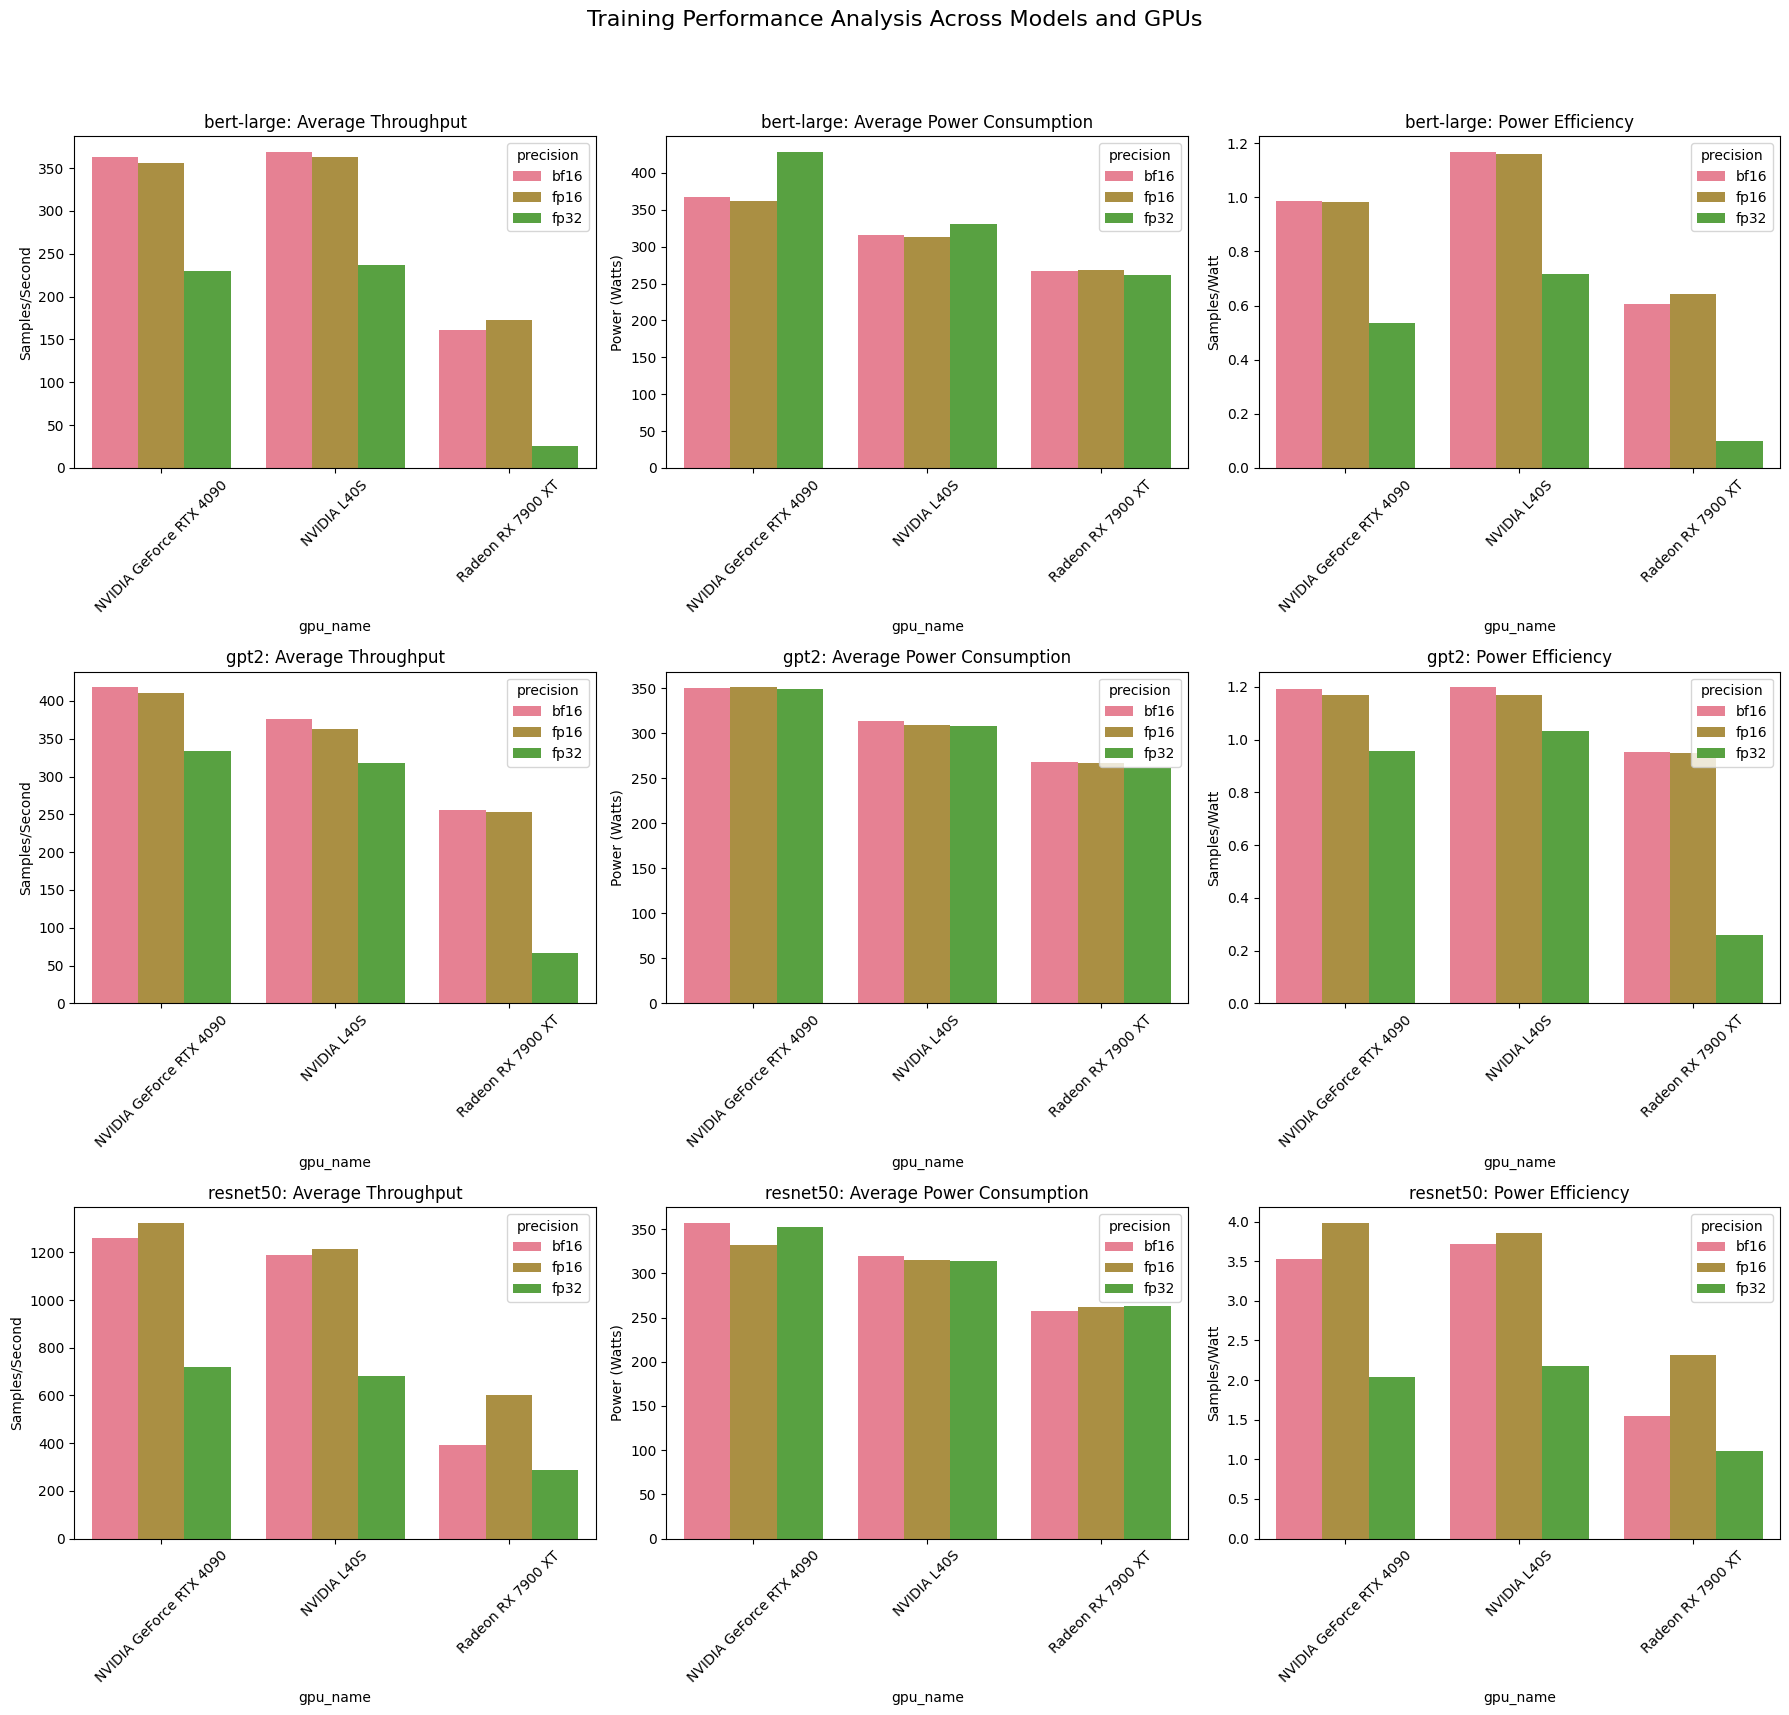

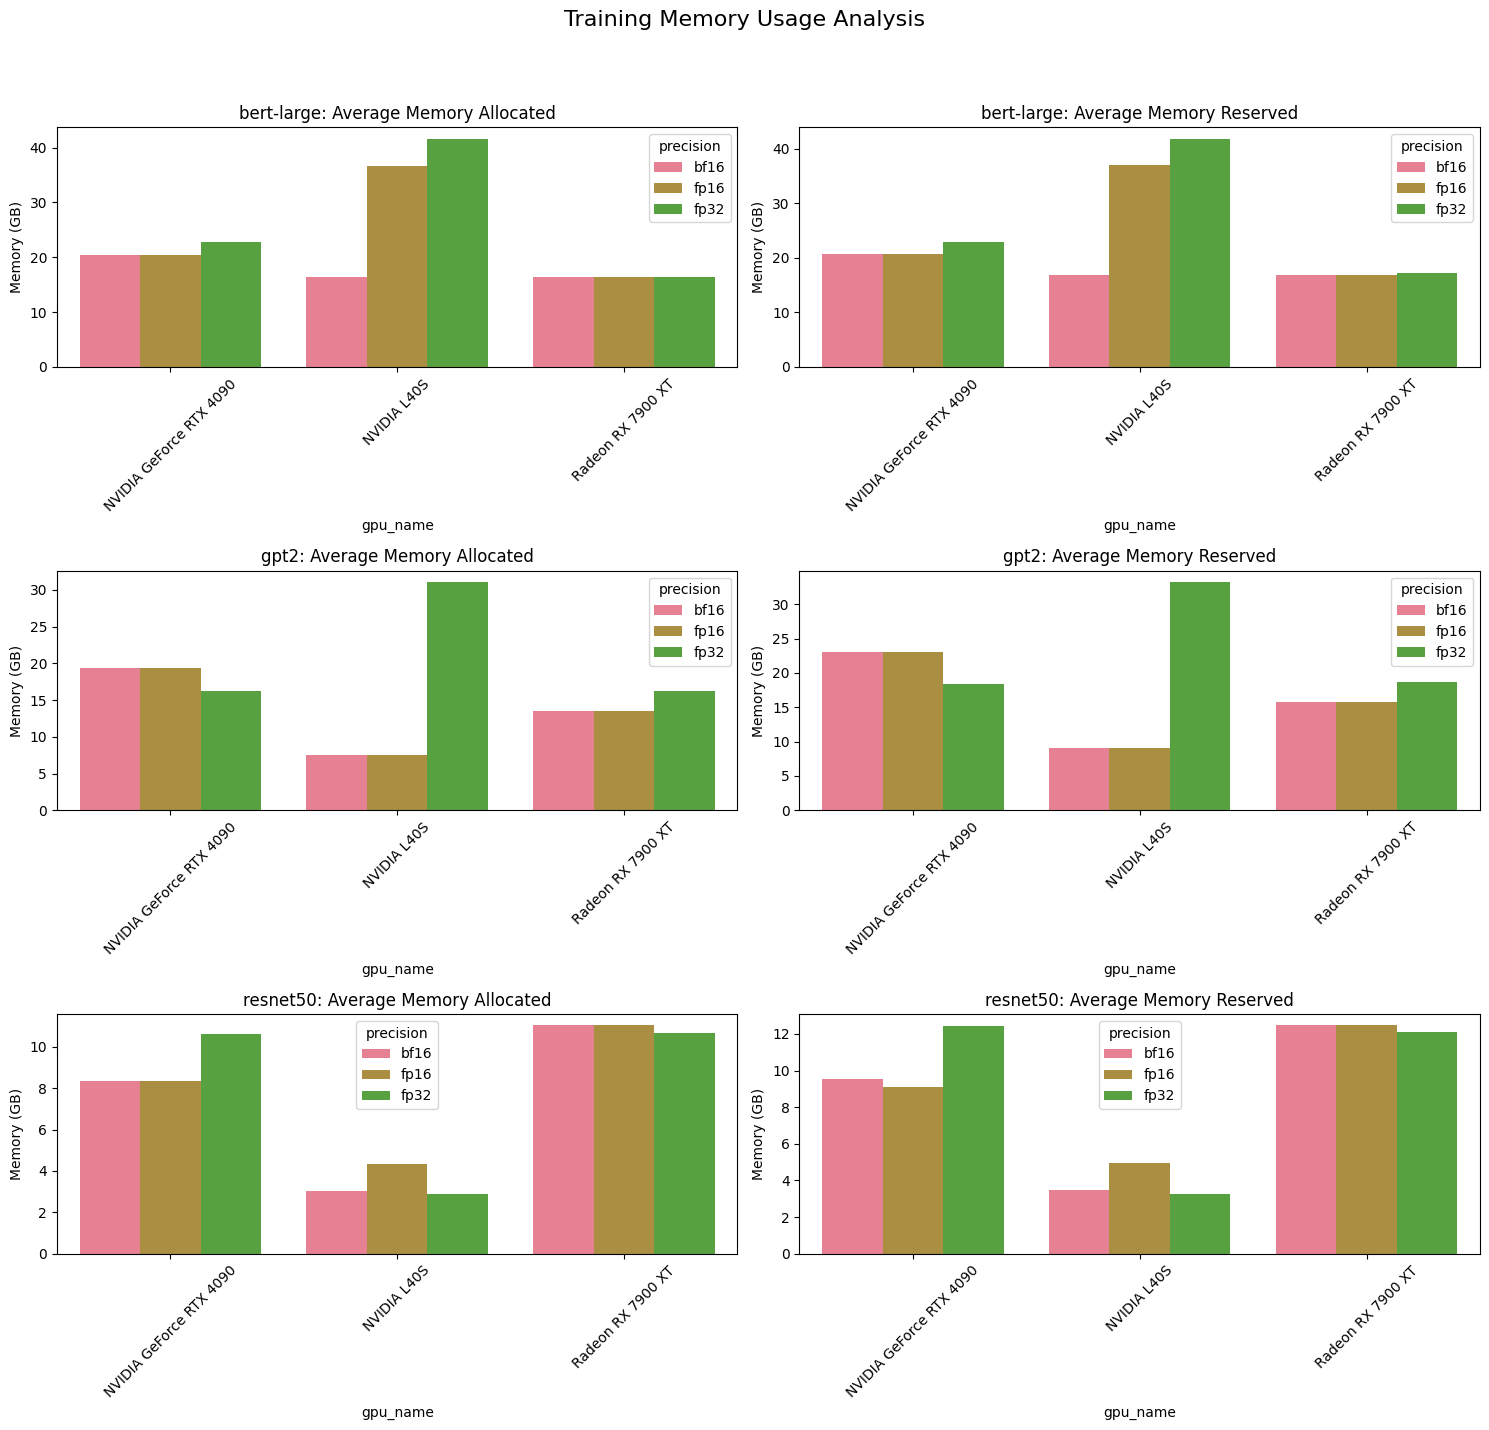

In [61]:
# Create training performance visualizations
if not training_df.empty and performance_summary is not None:
    # Convert multi-index to regular columns for plotting
    plot_data = performance_summary.reset_index()
    
    # Get unique models for separate plots
    models = plot_data['model'].unique()
    
    fig, axes = plt.subplots(len(models), 3, figsize=(18, 6*len(models)))
    if len(models) == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Training Performance Analysis Across Models and GPUs', fontsize=16, y=0.98)
    
    for i, model_name in enumerate(models):
        model_data = plot_data[plot_data['model'] == model_name]
        
        # Plot 1: Throughput comparison
        sns.barplot(data=model_data, x='gpu_name', y='avg_samples_per_sec', 
                   hue='precision', ax=axes[i, 0])
        axes[i, 0].set_title(f'{model_name}: Average Throughput')
        axes[i, 0].set_ylabel('Samples/Second')
        axes[i, 0].tick_params(axis='x', rotation=45)
        
        # Plot 2: Power consumption
        sns.barplot(data=model_data, x='gpu_name', y='avg_power_watts',
                   hue='precision', ax=axes[i, 1])
        axes[i, 1].set_title(f'{model_name}: Average Power Consumption')
        axes[i, 1].set_ylabel('Power (Watts)')
        axes[i, 1].tick_params(axis='x', rotation=45)
        
        # Plot 3: Power efficiency
        sns.barplot(data=model_data, x='gpu_name', y='avg_samples_per_watt',
                   hue='precision', ax=axes[i, 2])
        axes[i, 2].set_title(f'{model_name}: Power Efficiency')
        axes[i, 2].set_ylabel('Samples/Watt')
        axes[i, 2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # Create memory usage analysis
    fig, axes = plt.subplots(len(models), 2, figsize=(15, 5*len(models)))
    if len(models) == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Training Memory Usage Analysis', fontsize=16, y=0.98)
    
    for i, model_name in enumerate(models):
        model_data = plot_data[plot_data['model'] == model_name]
        
        # Memory allocation
        sns.barplot(data=model_data, x='gpu_name', y='avg_memory_alloc_gb',
                   hue='precision', ax=axes[i, 0])
        axes[i, 0].set_title(f'{model_name}: Average Memory Allocated')
        axes[i, 0].set_ylabel('Memory (GB)')
        axes[i, 0].tick_params(axis='x', rotation=45)
        
        # Memory reservation
        sns.barplot(data=model_data, x='gpu_name', y='avg_memory_reserved_gb',
                   hue='precision', ax=axes[i, 1])
        axes[i, 1].set_title(f'{model_name}: Average Memory Reserved')
        axes[i, 1].set_ylabel('Memory (GB)')
        axes[i, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Skipping training visualizations - no data available")

## 3. Power Consumption and Efficiency Analysis

Analyze power consumption patterns and calculate efficiency metrics relative to GPU TDP/TGP ratings.

Power Consumption Analysis
Power Efficiency Summary:
                                    avg_power_watts  power_usage_percent  performance_per_watt
gpu_name                model                                                                 
NVIDIA GeForce RTX 4090 bert-large           385.99                85.78                  0.84
                        gpt2                 350.43                77.87                  1.11
                        resnet50             347.48                77.22                  3.18
NVIDIA L40S             bert-large           319.79                91.37                  1.01
                        gpt2                 310.62                88.75                  1.13
                        resnet50             315.88                90.25                  3.25
Radeon RX 7900 XT       bert-large           265.73                84.36                  0.45
                        gpt2                 265.58                84.31                  0.

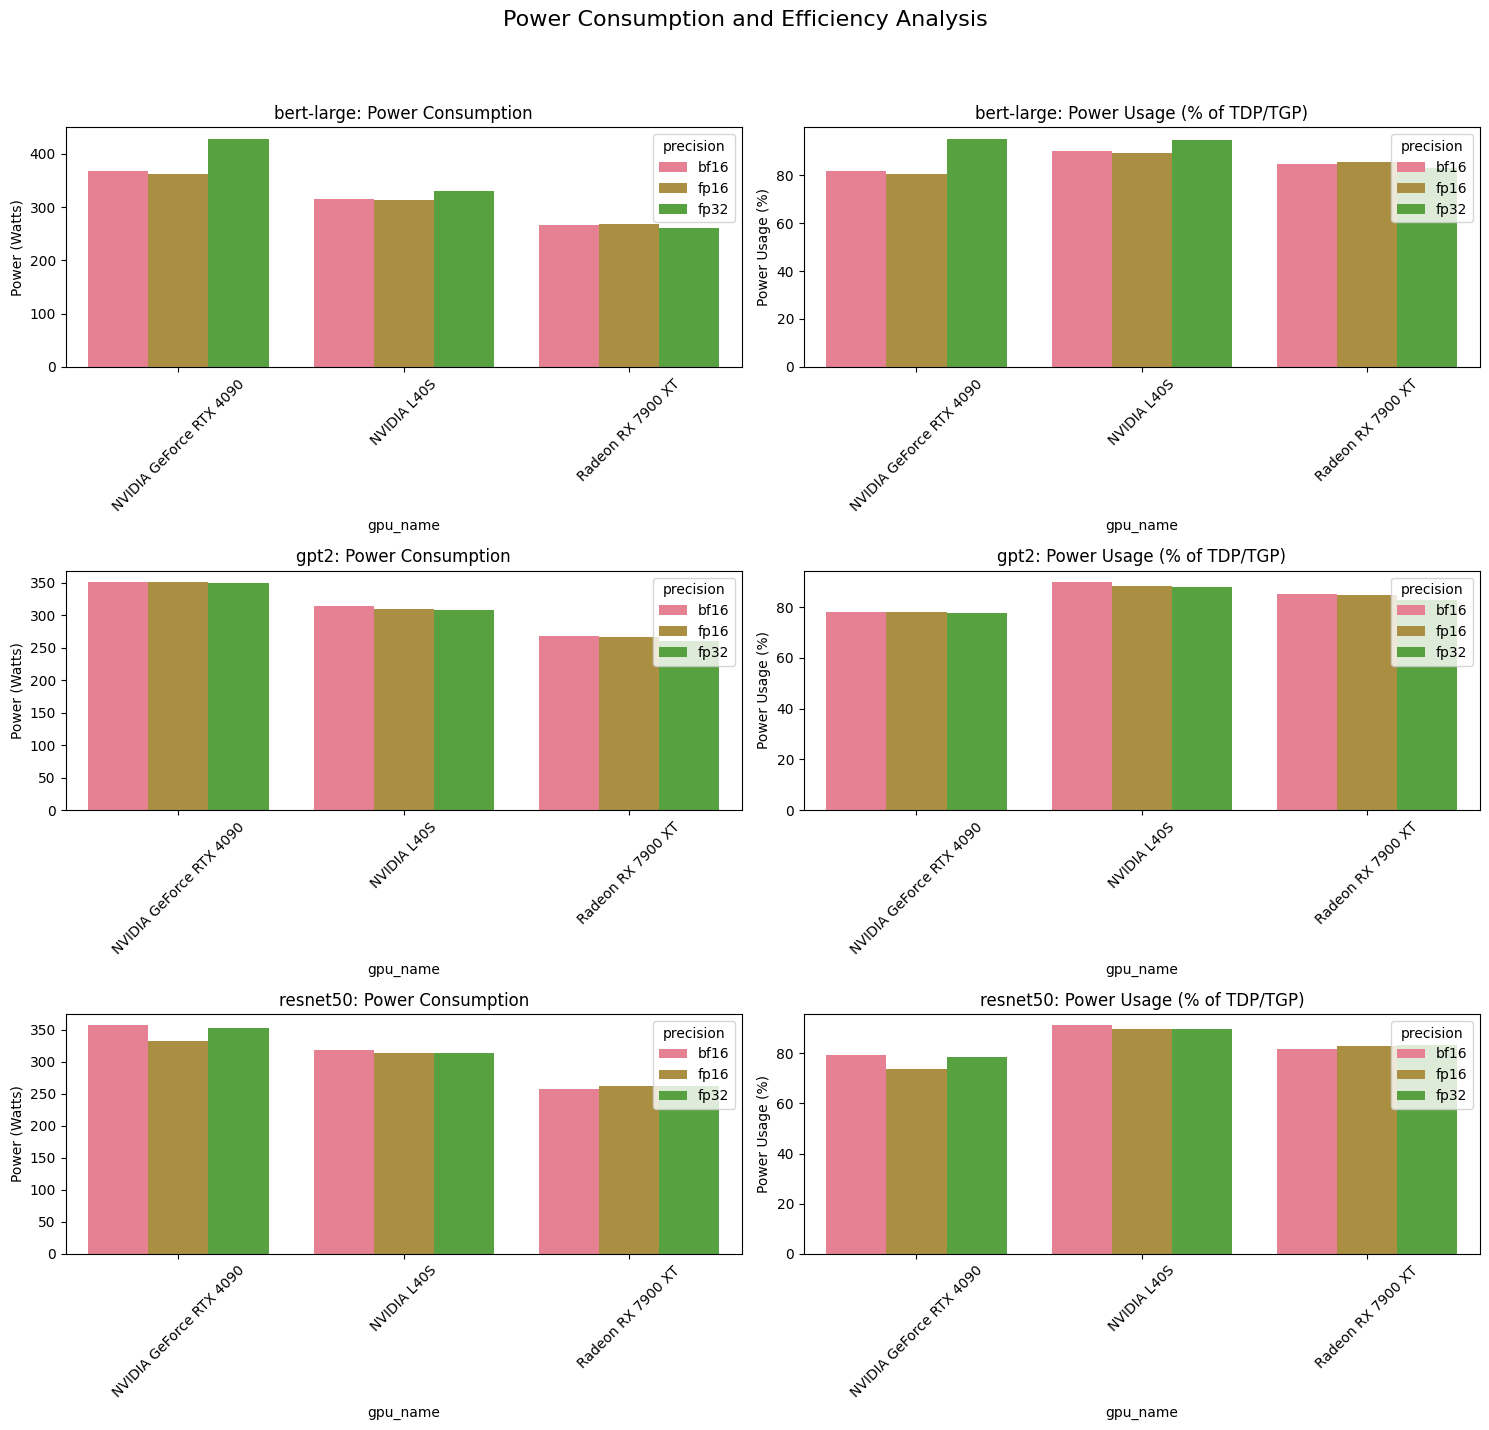

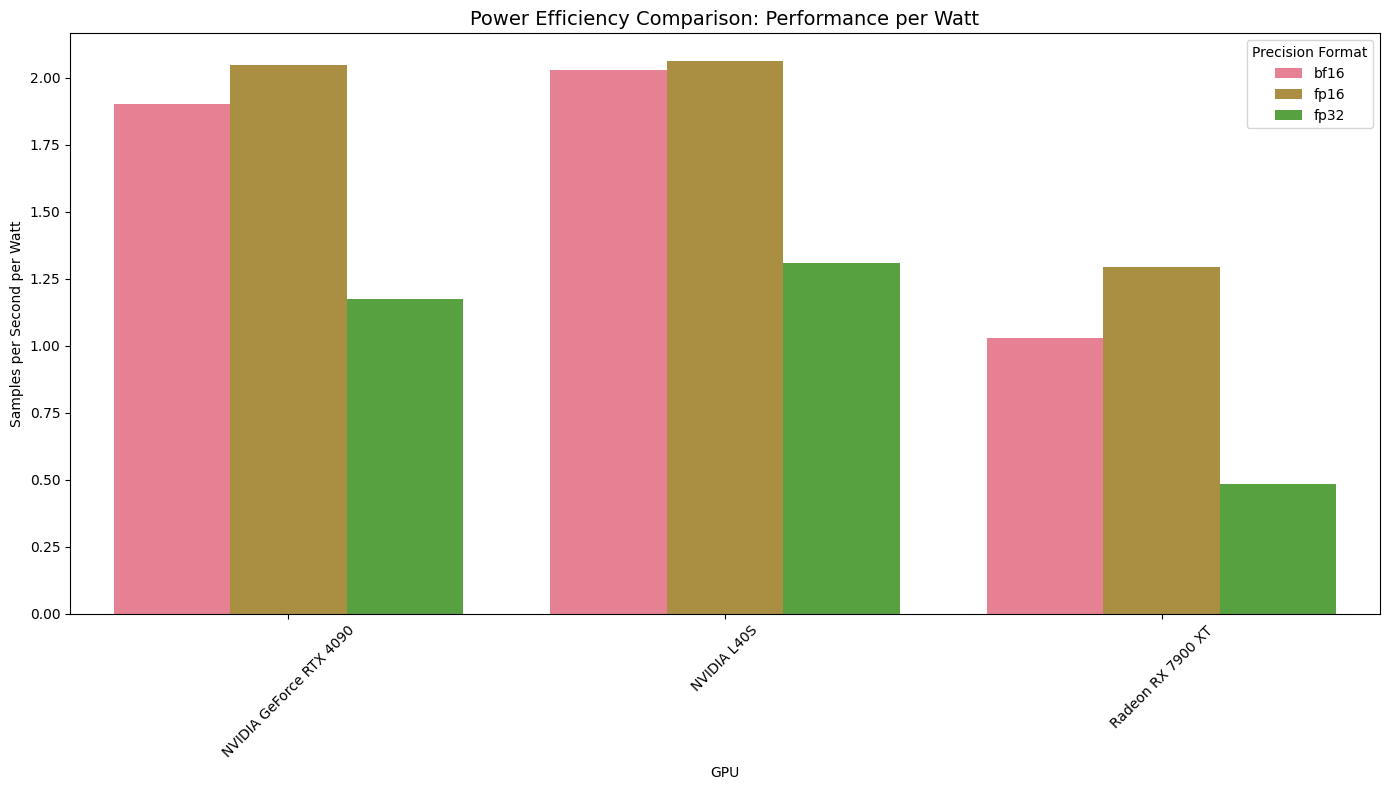


Most Power Efficient Configurations:
NVIDIA GeForce RTX 4090 + resnet50 + fp16: 3.9839 samples/watt (73.8% TDP)
NVIDIA L40S + resnet50 + fp16: 3.8563 samples/watt (89.9% TDP)
NVIDIA L40S + resnet50 + bf16: 3.7190 samples/watt (91.2% TDP)
NVIDIA GeForce RTX 4090 + resnet50 + bf16: 3.5242 samples/watt (79.4% TDP)
Radeon RX 7900 XT + resnet50 + fp16: 2.2973 samples/watt (83.1% TDP)


In [62]:
# GPU power ratings (TDP/TGP in Watts)
gpu_power_ratings = {
    'NVIDIA GeForce RTX 4090': 450,
    'NVIDIA L40S': 350,
    'Radeon RX 7900 XT': 315
}

def analyze_power_consumption(data_df, power_col='avg_power_watts', throughput_col='avg_samples_per_sec'):
    """Analyze power consumption and efficiency metrics."""
    
    if data_df.empty:
        return None
    
    df_analysis = data_df.copy()
    
    # Calculate power usage percentage
    df_analysis['power_usage_percent'] = df_analysis.apply(
        lambda row: (row[power_col] / gpu_power_ratings.get(row['gpu_name'], np.nan)) * 100
        if 'gpu_name' in row else np.nan,
        axis=1
    )
    
    # Calculate performance per watt
    df_analysis['performance_per_watt'] = df_analysis[throughput_col] / (df_analysis[power_col] + 1e-6)
    
    return df_analysis

# Analyze power consumption for training data
if performance_summary is not None:
    print("Power Consumption Analysis")
    print("=" * 50)
    
    plot_data = performance_summary.reset_index()
    power_analysis = analyze_power_consumption(plot_data)
    
    if power_analysis is not None:
        print("Power Efficiency Summary:")
        power_summary = power_analysis.groupby(['gpu_name', 'model']).agg({
            'avg_power_watts': 'mean',
            'power_usage_percent': 'mean', 
            'performance_per_watt': 'mean'
        }).round(2)
        
        print(power_summary)
        
        # Create power analysis visualizations
        models = power_analysis['model'].unique()
        
        fig, axes = plt.subplots(len(models), 2, figsize=(15, 5*len(models)))
        if len(models) == 1:
            axes = axes.reshape(1, -1)
        
        fig.suptitle('Power Consumption and Efficiency Analysis', fontsize=16, y=0.98)
        
        for i, model_name in enumerate(models):
            model_data = power_analysis[power_analysis['model'] == model_name]
            
            # Power consumption
            sns.barplot(data=model_data, x='gpu_name', y='avg_power_watts',
                       hue='precision', ax=axes[i, 0])
            axes[i, 0].set_title(f'{model_name}: Power Consumption')
            axes[i, 0].set_ylabel('Power (Watts)')
            axes[i, 0].tick_params(axis='x', rotation=45)
            
            # Power usage percentage
            sns.barplot(data=model_data, x='gpu_name', y='power_usage_percent',
                       hue='precision', ax=axes[i, 1])
            axes[i, 1].set_title(f'{model_name}: Power Usage (% of TDP/TGP)')
            axes[i, 1].set_ylabel('Power Usage (%)')
            axes[i, 1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        
        # Power efficiency comparison
        plt.figure(figsize=(14, 8))
        sns.barplot(data=power_analysis, x='gpu_name', y='performance_per_watt',
                   hue='precision', ci=None)
        plt.title('Power Efficiency Comparison: Performance per Watt', fontsize=14)
        plt.ylabel('Samples per Second per Watt')
        plt.xlabel('GPU')
        plt.xticks(rotation=45)
        plt.legend(title='Precision Format')
        plt.tight_layout()
        plt.show()
        
        # Best efficiency configurations
        print("\n" + "=" * 30)
        print("Most Power Efficient Configurations:")
        top_efficiency = power_analysis.nlargest(5, 'performance_per_watt')
        for _, row in top_efficiency.iterrows():
            print(f"{row['gpu_name']} + {row['model']} + {row['precision']}: "
                  f"{row['performance_per_watt']:.4f} samples/watt "
                  f"({row['power_usage_percent']:.1f}% TDP)")

else:
    print("No training data available for power analysis")

## 4. Inference Performance Comparison

Analyze inference throughput and memory usage across different configurations, identifying optimal batch sizes and device-specific characteristics.

Inference Metrics Analysis:
------------------------------
Device Performance Summary:
        mean_throughput  std_throughput  mean_peak_memory_mb  count  efficiency_throughput_per_mb
device                                                                                           
4090            2259.04         1453.71              1458.04    900                        1.5494
7900            1038.35          889.76              2035.86   1705                        0.5100
L40S            2165.31         1221.58              1330.25   1861                        1.6277

Inference Batch Size Analysis:
------------------------------
Optimal Batch Sizes (Maximum Throughput):
NVIDIA GeForce RTX 4090 + bert-large + bf16: batch_size=64, throughput=1427.5
NVIDIA GeForce RTX 4090 + bert-large + fp16: batch_size=64, throughput=1427.3
NVIDIA GeForce RTX 4090 + bert-large + fp32: batch_size=32, throughput=819.0
NVIDIA GeForce RTX 4090 + gpt2 + bf16: batch_size=32, throughput=1476.5
NVIDIA GeForc

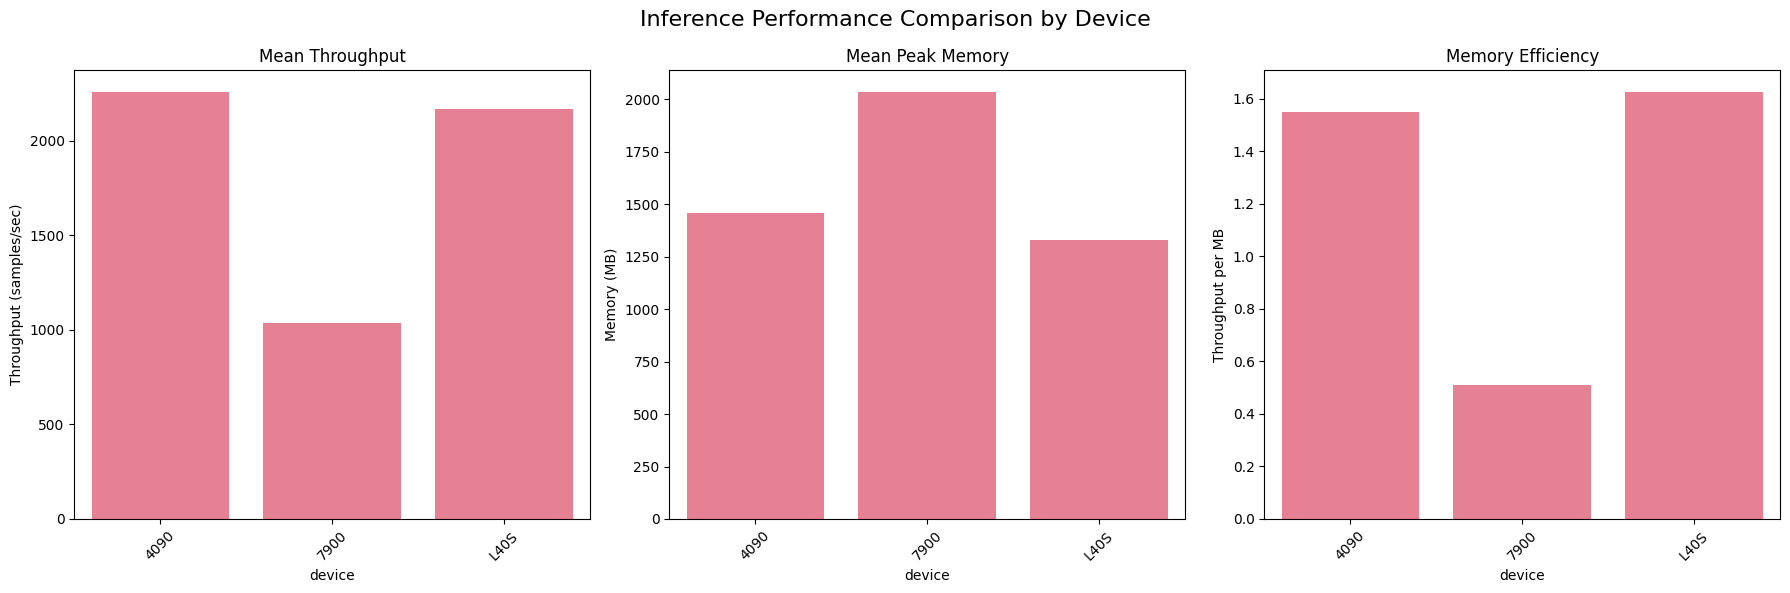

Creating batch size analysis visualizations...


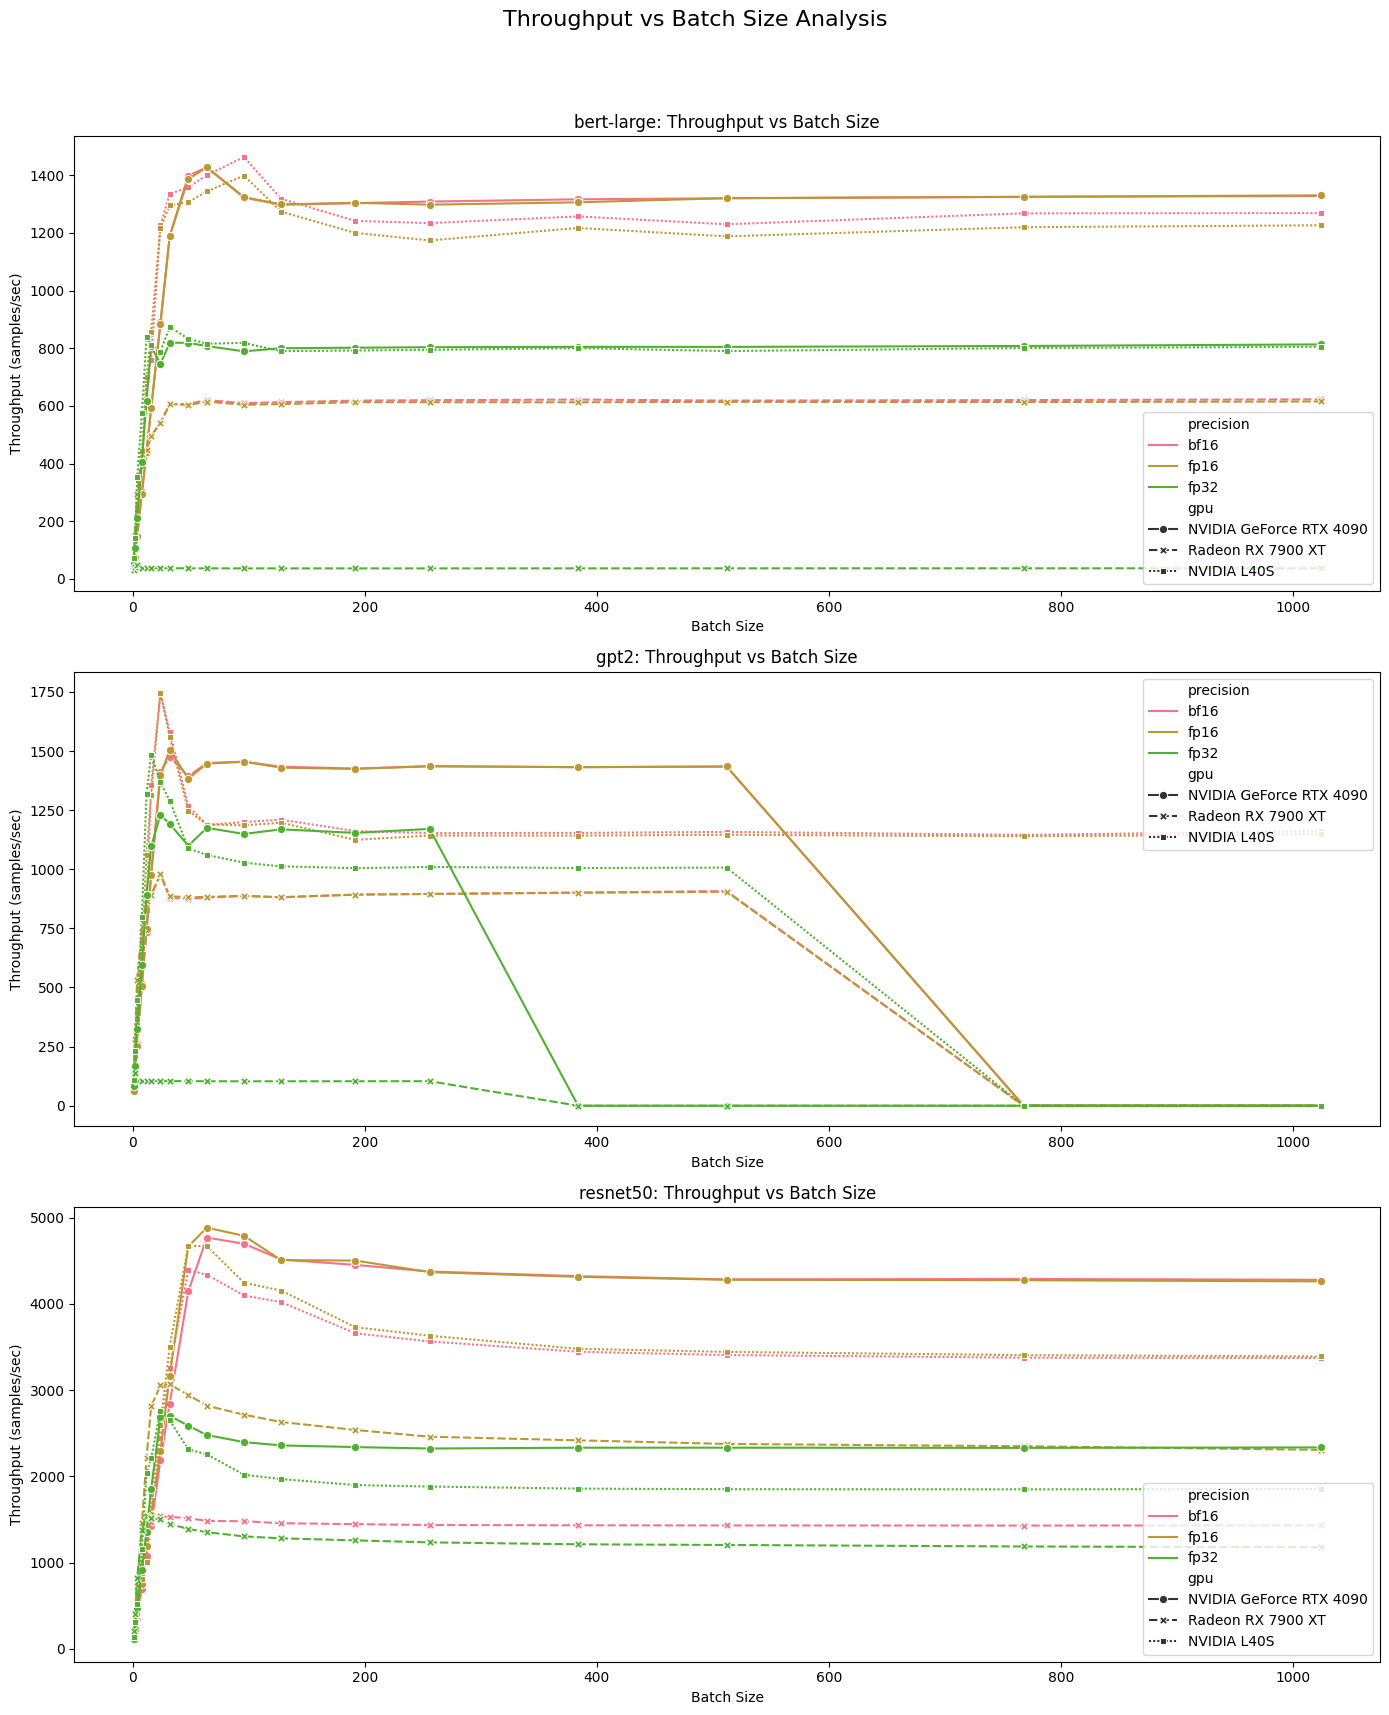

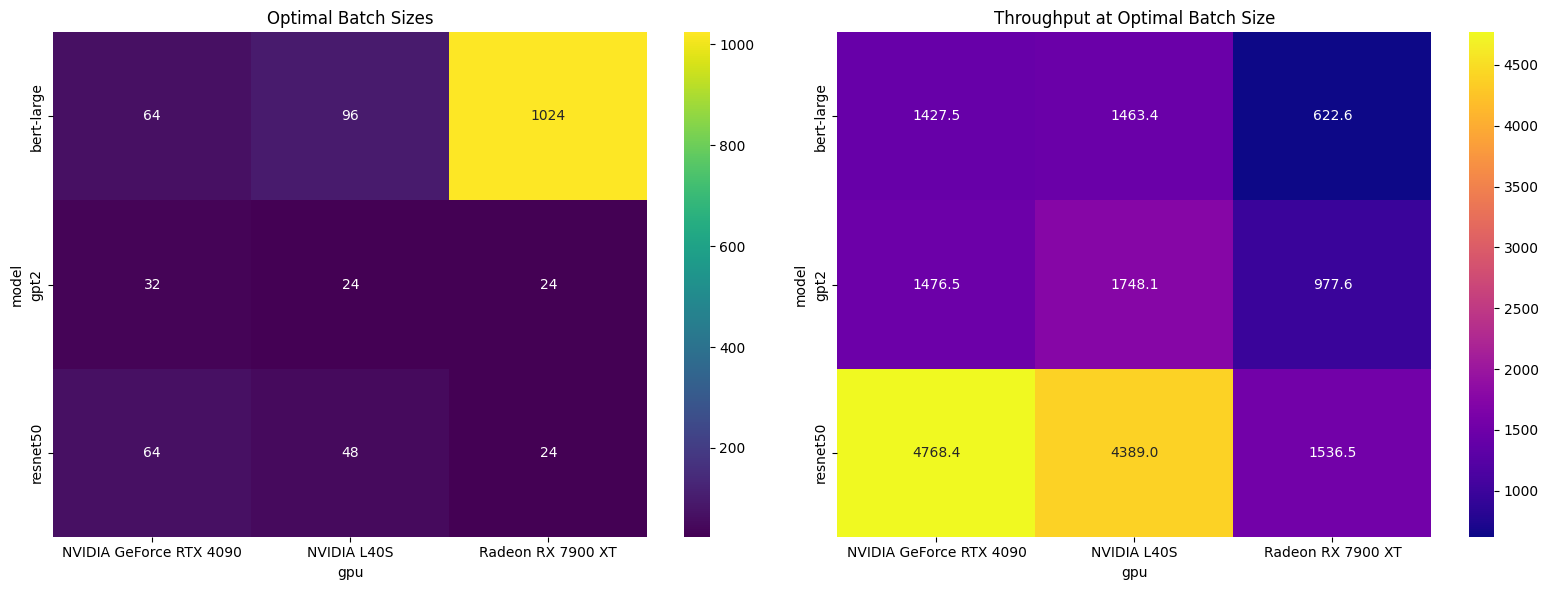

In [63]:
def analyze_inference_performance(inference_df, inference_batch_df):
    """Analyze inference performance across different configurations."""
    
    results = {}
    
    # Analyze inference metrics if available
    if not inference_df.empty:
        print("Inference Metrics Analysis:")
        print("-" * 30)
        
        # Device performance summary
        device_summary = inference_df.groupby('device').agg(
            mean_throughput=('throughput_samples_per_sec', 'mean'),
            std_throughput=('throughput_samples_per_sec', 'std'),
            mean_peak_memory_mb=('peak_memory_mb', 'mean'),
            count=('device', 'count')
        ).round(2)
        
        # Calculate efficiency
        device_summary['efficiency_throughput_per_mb'] = (
            device_summary['mean_throughput'] / device_summary['mean_peak_memory_mb']
        ).round(4)
        
        results['device_summary'] = device_summary
        print("Device Performance Summary:")
        print(device_summary)
    
    # Analyze batch size experiments if available  
    if not inference_batch_df.empty:
        print(f"\nInference Batch Size Analysis:")
        print("-" * 30)
        
        # Find optimal batch sizes
        optimal_batch = inference_batch_df.groupby(['gpu', 'model', 'precision']).apply(
            lambda x: x.loc[x['throughput'].idxmax()]
        ).reset_index(drop=True)
        
        results['optimal_batch'] = optimal_batch
        
        print("Optimal Batch Sizes (Maximum Throughput):")
        for _, row in optimal_batch.iterrows():
            print(f"{row['gpu']} + {row['model']} + {row['precision']}: "
                  f"batch_size={row['batch_size']}, throughput={row['throughput']:.1f}")
    
    return results

# Analyze inference performance
inference_results = analyze_inference_performance(inference_df, inference_batch_df)

# Create inference visualizations
if not inference_df.empty:
    print(f"\nCreating inference performance visualizations...")
    
    # Device comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Inference Performance Comparison by Device', fontsize=16)
    
    device_summary = inference_results.get('device_summary')
    if device_summary is not None:
        device_data = device_summary.reset_index()
        
        # Throughput
        sns.barplot(data=device_data, x='device', y='mean_throughput', ax=axes[0])
        axes[0].set_title('Mean Throughput')
        axes[0].set_ylabel('Throughput (samples/sec)')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Memory usage
        sns.barplot(data=device_data, x='device', y='mean_peak_memory_mb', ax=axes[1])
        axes[1].set_title('Mean Peak Memory')
        axes[1].set_ylabel('Memory (MB)')
        axes[1].tick_params(axis='x', rotation=45)
        
        # Efficiency
        sns.barplot(data=device_data, x='device', y='efficiency_throughput_per_mb', ax=axes[2])
        axes[2].set_title('Memory Efficiency')
        axes[2].set_ylabel('Throughput per MB')
        axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Batch size analysis visualizations
if not inference_batch_df.empty:
    print("Creating batch size analysis visualizations...")
    
    models = inference_batch_df['model'].unique()
    
    # Throughput vs batch size plots
    fig, axes = plt.subplots(len(models), 1, figsize=(14, 6*len(models)))
    if len(models) == 1:
        axes = [axes]
    
    fig.suptitle('Throughput vs Batch Size Analysis', fontsize=16, y=0.98)
    
    for i, model_name in enumerate(models):
        model_data = inference_batch_df[inference_batch_df['model'] == model_name]
        
        sns.lineplot(data=model_data, x='batch_size', y='throughput',
                    hue='precision', style='gpu', markers=True, ax=axes[i])
        axes[i].set_title(f'{model_name}: Throughput vs Batch Size')
        axes[i].set_ylabel('Throughput (samples/sec)')
        axes[i].set_xlabel('Batch Size')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    
    # Create heatmap of optimal batch sizes
    if 'optimal_batch' in inference_results:
        optimal_data = inference_results['optimal_batch']
        
        # Create pivot table for heatmap
        batch_pivot = optimal_data.pivot_table(
            values='batch_size', 
            index='model', 
            columns='gpu',
            aggfunc='first'
        )
        
        throughput_pivot = optimal_data.pivot_table(
            values='throughput',
            index='model', 
            columns='gpu',
            aggfunc='first'
        )
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Optimal batch sizes
        sns.heatmap(batch_pivot, annot=True, fmt='.0f', cmap='viridis', ax=axes[0])
        axes[0].set_title('Optimal Batch Sizes')
        
        # Corresponding throughput
        sns.heatmap(throughput_pivot, annot=True, fmt='.1f', cmap='plasma', ax=axes[1]) 
        axes[1].set_title('Throughput at Optimal Batch Size')
        
        plt.tight_layout()
        plt.show()

else:
    print("No inference batch data available for visualization")

## 5. Precision Format Impact Analysis

Analyze the performance impact of different precision formats and calculate comprehensive efficiency scores.

Precision Format Impact Analysis
Best performing configurations by precision format:
          avg_throughput_samples_per_sec          throughput_per_watt        throughput_per_gb         efficiency_score       
                                    mean      std                mean    std              mean     std             mean    std
precision                                                                                                                     
bf16                             487.200  405.774               1.797  1.368            48.866  78.831            0.532  0.322
fp16                             493.422  421.495               1.838  1.471            48.262  67.503            0.549  0.344
fp32                             293.038  244.021               1.047  0.918            28.887  49.991            0.270  0.171


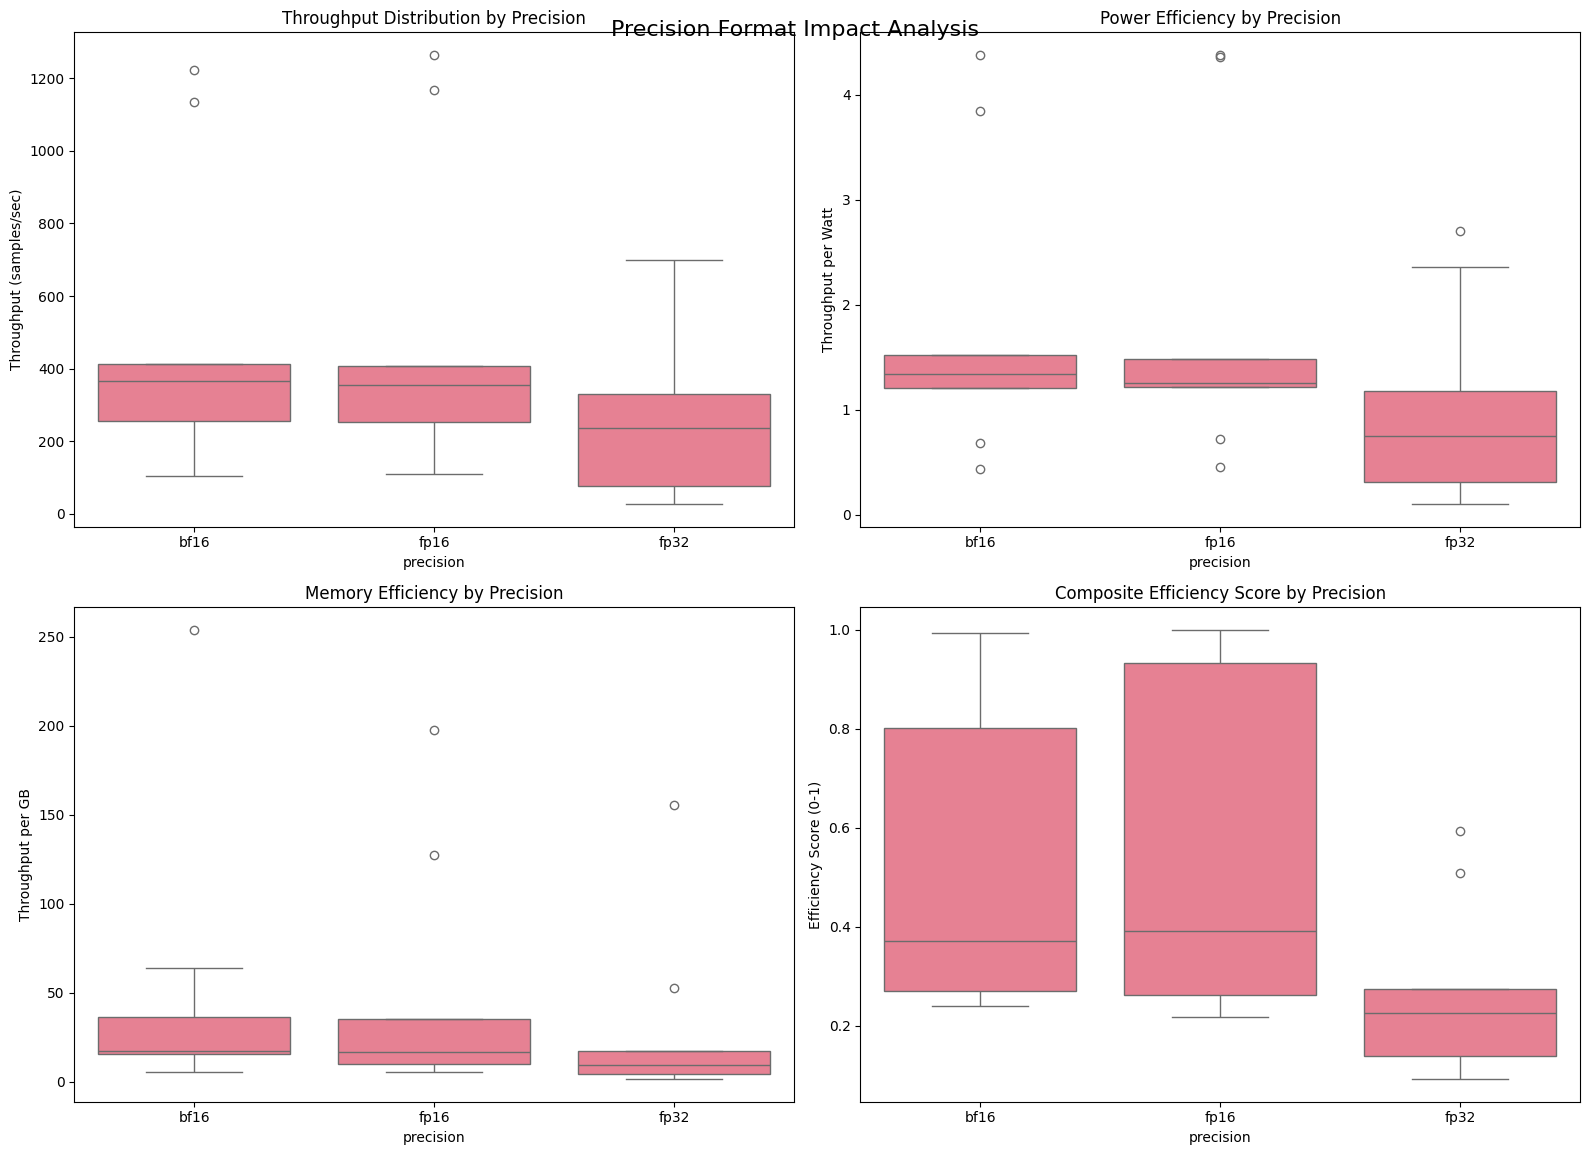


Performance relative to FP32 baseline:
FP16:
  Throughput: +68.4% vs FP32
  Power Efficiency: +75.6% vs FP32
BF16:
  Throughput: +66.3% vs FP32
  Power Efficiency: +71.7% vs FP32

Top 10 Most Efficient Configurations:
 1. NVIDIA GeForce RTX 4090 + resnet50 + fp16
    Score: 1.000 | Throughput: 1265.0 samples/sec | Efficiency: 4.355 samples/watt
 2. Radeon RX 7900 XT + gpt2 + bf16
    Score: 0.994 | Throughput: 256.2 samples/sec | Efficiency: 1.208 samples/watt
 3. Radeon RX 7900 XT + gpt2 + fp16
    Score: 0.992 | Throughput: 253.1 samples/sec | Efficiency: 1.232 samples/watt
 4. NVIDIA L40S + resnet50 + bf16
    Score: 0.989 | Throughput: 1135.9 samples/sec | Efficiency: 4.379 samples/watt
 5. NVIDIA L40S + resnet50 + fp16
    Score: 0.933 | Throughput: 1166.7 samples/sec | Efficiency: 4.377 samples/watt
 6. NVIDIA GeForce RTX 4090 + resnet50 + bf16
    Score: 0.802 | Throughput: 1222.0 samples/sec | Efficiency: 3.843 samples/watt
 7. Radeon RX 7900 XT + bert-large + fp16
    Score: 

In [64]:
def analyze_precision_impact(precision_batch_df):
    """Analyze the impact of different precision formats per GPU."""
    
    if precision_batch_df.empty:
        print("No precision batch data available")
        return None
    
    # Find best configuration for each GPU, model, and precision
    best_configs = precision_batch_df.groupby(['gpu_name', 'model', 'precision']).apply(
        lambda x: x.loc[x['avg_throughput_samples_per_sec'].idxmax()]
    ).reset_index(drop=True)
    
    # Calculate efficiency metrics
    best_configs['throughput_per_watt'] = (
        best_configs['avg_throughput_samples_per_sec'] / 
        (best_configs['avg_power_watts'] + 1e-6)
    )
    
    best_configs['throughput_per_gb'] = (
        best_configs['avg_throughput_samples_per_sec'] / 
        (best_configs['peak_memory_mb'] / 1024 + 1e-6)
    )
    
    # Calculate composite efficiency score per GPU
    for gpu in best_configs['gpu_name'].unique():
        gpu_data = best_configs[best_configs['gpu_name'] == gpu]
        
        if not gpu_data.empty:
            # Normalize within each GPU
            best_configs.loc[best_configs['gpu_name'] == gpu, 'efficiency_score'] = (
                0.4 * gpu_data['avg_throughput_samples_per_sec'] / gpu_data['avg_throughput_samples_per_sec'].max() +
                0.3 * gpu_data['throughput_per_watt'] / gpu_data['throughput_per_watt'].max() +
                0.3 * gpu_data['throughput_per_gb'] / gpu_data['throughput_per_gb'].max()
            )
    
    return best_configs

# Analyze precision impact
if not precision_batch_df.empty:
    print("Precision Format Impact Analysis")
    print("=" * 50)
    
    precision_analysis = analyze_precision_impact(precision_batch_df)
    
    if precision_analysis is not None:
        print("Best performing configurations by precision format:")
        
        # Performance comparison by precision
        precision_summary = precision_analysis.groupby('precision').agg({
            'avg_throughput_samples_per_sec': ['mean', 'std'],
            'throughput_per_watt': ['mean', 'std'],
            'throughput_per_gb': ['mean', 'std'],
            'efficiency_score': ['mean', 'std']
        }).round(3)
        
        print(precision_summary)
        
        # Create precision comparison visualizations
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Precision Format Impact Analysis', fontsize=16, y=0.95)
        
        # Throughput by precision
        sns.boxplot(data=precision_analysis, x='precision', y='avg_throughput_samples_per_sec', ax=axes[0, 0])
        axes[0, 0].set_title('Throughput Distribution by Precision')
        axes[0, 0].set_ylabel('Throughput (samples/sec)')
        
        # Power efficiency by precision
        sns.boxplot(data=precision_analysis, x='precision', y='throughput_per_watt', ax=axes[0, 1])
        axes[0, 1].set_title('Power Efficiency by Precision')
        axes[0, 1].set_ylabel('Throughput per Watt')
        
        # Memory efficiency by precision
        sns.boxplot(data=precision_analysis, x='precision', y='throughput_per_gb', ax=axes[1, 0])
        axes[1, 0].set_title('Memory Efficiency by Precision')
        axes[1, 0].set_ylabel('Throughput per GB')
        
        # Composite efficiency score
        sns.boxplot(data=precision_analysis, x='precision', y='efficiency_score', ax=axes[1, 1])
        axes[1, 1].set_title('Composite Efficiency Score by Precision')
        axes[1, 1].set_ylabel('Efficiency Score (0-1)')
        
        plt.tight_layout()
        plt.show()
        
        # Relative performance analysis (compared to FP32)
        fp32_baseline = precision_analysis[precision_analysis['precision'] == 'fp32']
        
        if not fp32_baseline.empty:
            print("\nPerformance relative to FP32 baseline:")
            
            for precision in ['fp16', 'bf16']:
                precision_data = precision_analysis[precision_analysis['precision'] == precision]
                
                if not precision_data.empty:
                    # Calculate mean improvements
                    throughput_improvement = (
                        (precision_data['avg_throughput_samples_per_sec'].mean() - 
                         fp32_baseline['avg_throughput_samples_per_sec'].mean()) /
                        fp32_baseline['avg_throughput_samples_per_sec'].mean() * 100
                    )
                    
                    efficiency_improvement = (
                        (precision_data['throughput_per_watt'].mean() - 
                         fp32_baseline['throughput_per_watt'].mean()) /
                        fp32_baseline['throughput_per_watt'].mean() * 100
                    )
                    
                    print(f"{precision.upper()}:")
                    print(f"  Throughput: {throughput_improvement:+.1f}% vs FP32")
                    print(f"  Power Efficiency: {efficiency_improvement:+.1f}% vs FP32")
        
        # Top efficiency configurations
        print("\n" + "=" * 30)
        print("Top 10 Most Efficient Configurations:")
        top_efficient = precision_analysis.nlargest(10, 'efficiency_score')
        
        for i, (_, row) in enumerate(top_efficient.iterrows(), 1):
            print(f"{i:2d}. {row['gpu']} + {row['model']} + {row['precision']}")
            print(f"    Score: {row['efficiency_score']:.3f} | "
                  f"Throughput: {row['avg_throughput_samples_per_sec']:.1f} samples/sec | "
                  f"Efficiency: {row['throughput_per_watt']:.3f} samples/watt")

else:
    print("No precision batch data available for analysis")

## 6. Cross-GPU Performance Comparison

Compare performance characteristics across different GPU platforms, highlighting strengths and optimal use cases.

Cross-GPU Performance Comparison
Training Performance by GPU:
                         avg_throughput_samples_per_sec  avg_power_watts  peak_memory_mb  avg_utilization_percent
gpu                                                                                                              
NVIDIA GeForce RTX 4090                          679.23           174.13         8804.82                    48.43
NVIDIA L40S                                      632.32           218.22        12992.78                    62.09
Radeon RX 7900 XT                                179.38           181.21         7209.15                    67.42


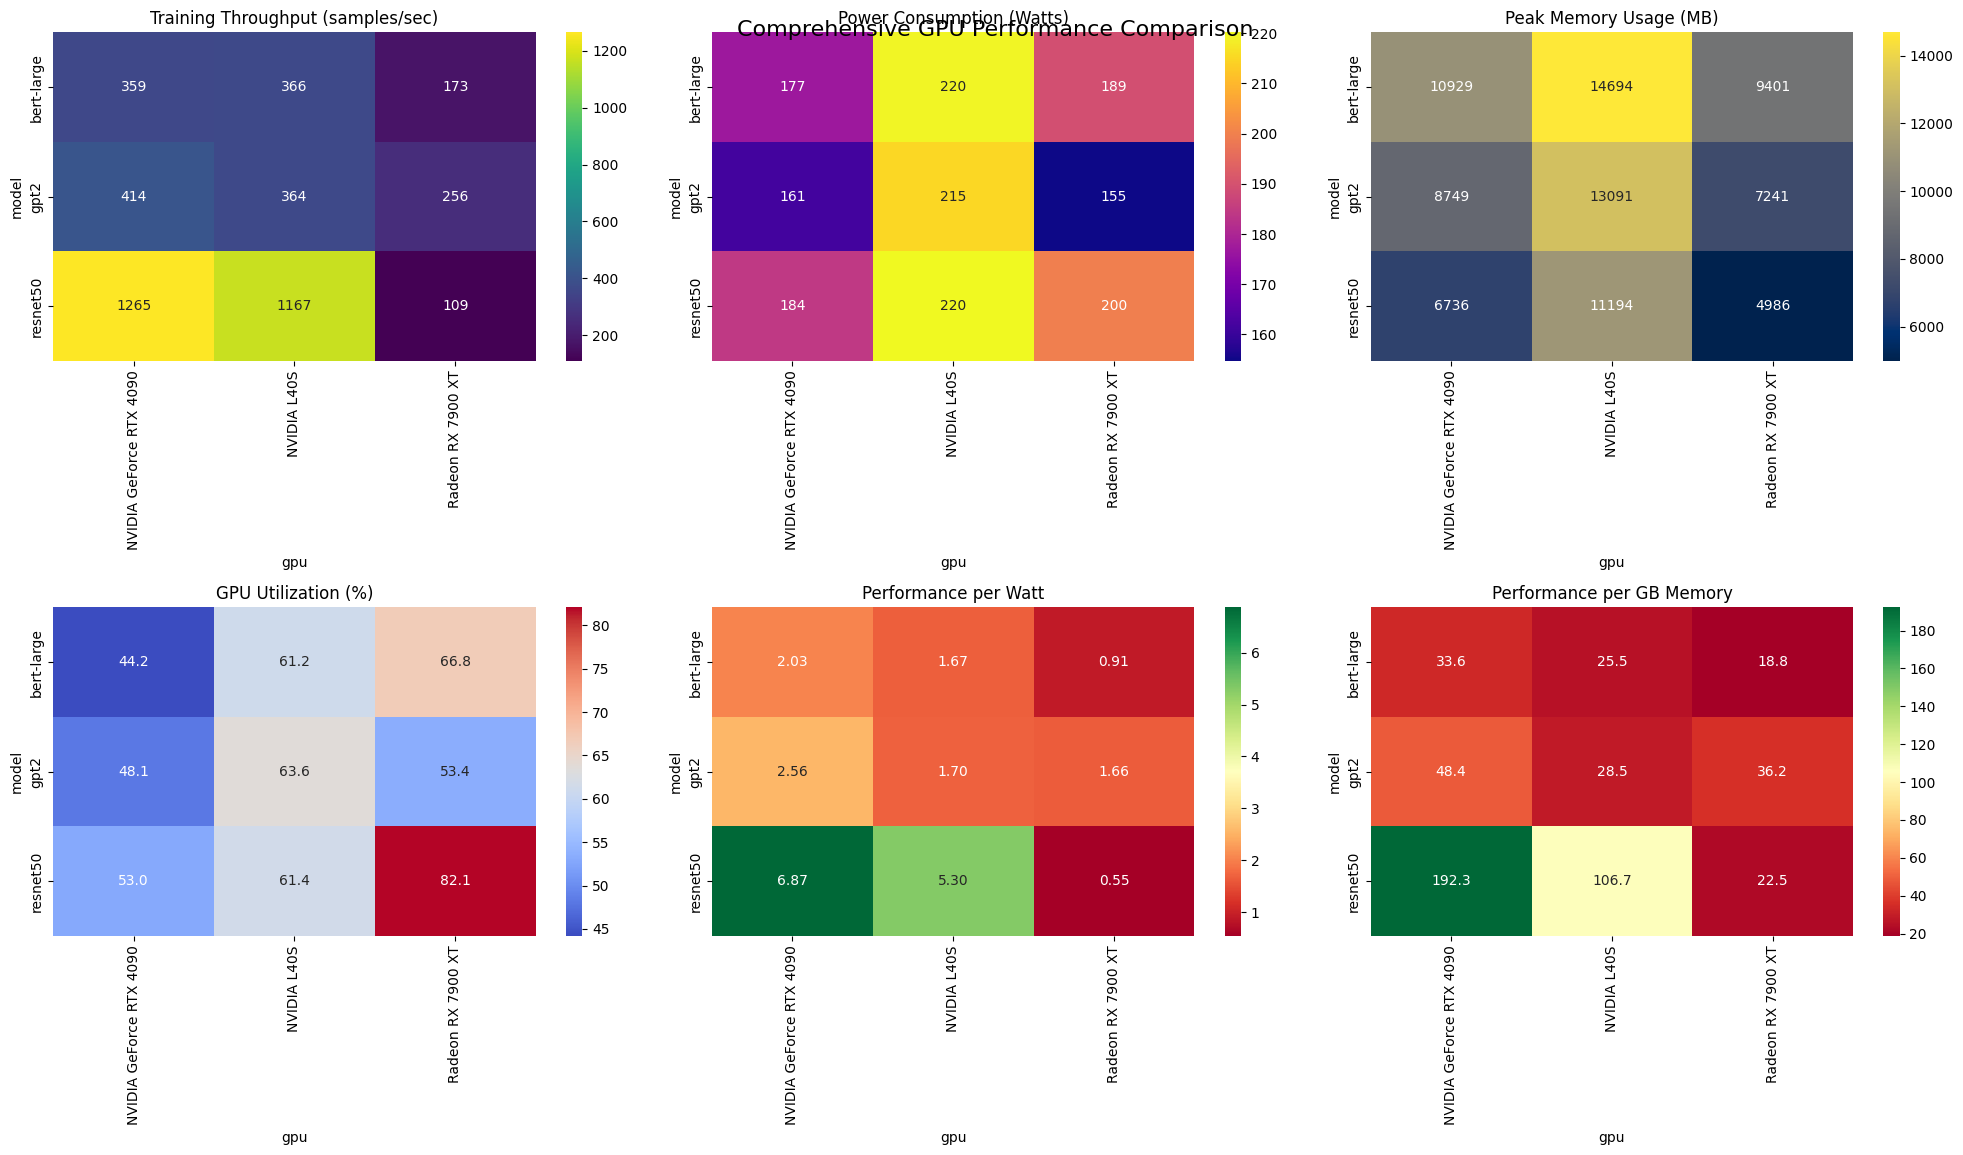


Inference Performance by GPU:
                         throughput  batch_size
gpu                                            
NVIDIA GeForce RTX 4090     2604.87      198.39
NVIDIA L40S                 2627.75      198.39
Radeon RX 7900 XT           1555.99      198.39


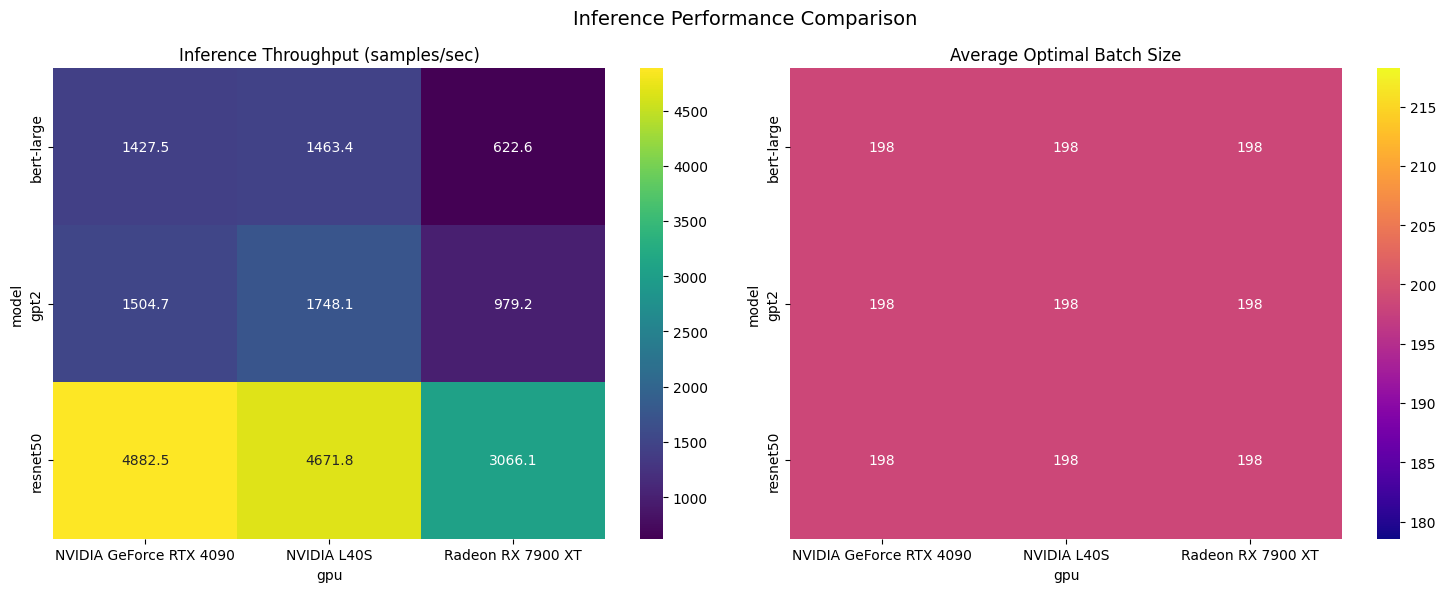


GPU Performance Rankings:

Overall GPU Rankings (by efficiency score):
1. NVIDIA GeForce RTX 4090
   Efficiency Score: 0.558
   Max Throughput: 1265 samples/sec
   Avg Power: 175W
   Avg Memory: 8605MB

2. NVIDIA L40S
   Efficiency Score: 0.369
   Max Throughput: 1167 samples/sec
   Avg Power: 218W
   Avg Memory: 12839MB

3. Radeon RX 7900 XT
   Efficiency Score: 0.266
   Max Throughput: 256 samples/sec
   Avg Power: 184W
   Avg Memory: 6976MB



In [65]:
def create_gpu_comparison_analysis(precision_batch_df, inference_batch_df):
    """Create comprehensive GPU comparison analysis."""
    
    gpu_analysis = {}
    
    # Training performance comparison
    if not precision_batch_df.empty:
        training_gpu_summary = precision_batch_df.groupby(['gpu', 'model']).agg({
            'avg_throughput_samples_per_sec': 'max',
            'avg_power_watts': 'mean',
            'peak_memory_mb': 'mean',
            'avg_utilization_percent': 'mean'
        }).round(2)
        
        gpu_analysis['training'] = training_gpu_summary
    
    # Inference performance comparison  
    if not inference_batch_df.empty:
        inference_gpu_summary = inference_batch_df.groupby(['gpu', 'model']).agg({
            'throughput': 'max',
            'batch_size': 'mean'
        }).round(2)
        
        gpu_analysis['inference'] = inference_gpu_summary
    
    return gpu_analysis

# Create GPU comparison analysis
gpu_comparison = create_gpu_comparison_analysis(precision_batch_df, inference_batch_df)

if gpu_comparison:
    print("Cross-GPU Performance Comparison")
    print("=" * 50)
    
    # Training comparison
    if 'training' in gpu_comparison:
        training_data = gpu_comparison['training'].reset_index()
        
        print("Training Performance by GPU:")
        gpu_training_avg = training_data.groupby('gpu').agg({
            'avg_throughput_samples_per_sec': 'mean',
            'avg_power_watts': 'mean',
            'peak_memory_mb': 'mean',
            'avg_utilization_percent': 'mean'
        }).round(2)
        
        print(gpu_training_avg)
        
        # Create comprehensive GPU comparison visualization
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle('Comprehensive GPU Performance Comparison', fontsize=16, y=0.95)
        
        # Training throughput by GPU and model
        training_pivot = training_data.pivot(index='model', columns='gpu', values='avg_throughput_samples_per_sec')
        sns.heatmap(training_pivot, annot=True, fmt='.0f', cmap='viridis', ax=axes[0, 0])
        axes[0, 0].set_title('Training Throughput (samples/sec)')
        
        # Power consumption by GPU and model
        power_pivot = training_data.pivot(index='model', columns='gpu', values='avg_power_watts')
        sns.heatmap(power_pivot, annot=True, fmt='.0f', cmap='plasma', ax=axes[0, 1])
        axes[0, 1].set_title('Power Consumption (Watts)')
        
        # Memory usage by GPU and model
        memory_pivot = training_data.pivot(index='model', columns='gpu', values='peak_memory_mb')
        sns.heatmap(memory_pivot, annot=True, fmt='.0f', cmap='cividis', ax=axes[0, 2])
        axes[0, 2].set_title('Peak Memory Usage (MB)')
        
        # GPU utilization
        util_pivot = training_data.pivot(index='model', columns='gpu', values='avg_utilization_percent')
        sns.heatmap(util_pivot, annot=True, fmt='.1f', cmap='coolwarm', ax=axes[1, 0])
        axes[1, 0].set_title('GPU Utilization (%)')
        
        # Performance per watt comparison
        training_data['perf_per_watt'] = training_data['avg_throughput_samples_per_sec'] / training_data['avg_power_watts']
        perf_watt_pivot = training_data.pivot(index='model', columns='gpu', values='perf_per_watt')
        sns.heatmap(perf_watt_pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1, 1])
        axes[1, 1].set_title('Performance per Watt')
        
        # Memory efficiency
        training_data['perf_per_gb'] = training_data['avg_throughput_samples_per_sec'] / (training_data['peak_memory_mb'] / 1024)
        perf_mem_pivot = training_data.pivot(index='model', columns='gpu', values='perf_per_gb')
        sns.heatmap(perf_mem_pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1, 2])
        axes[1, 2].set_title('Performance per GB Memory')
        
        plt.tight_layout()
        plt.show()
    
    # Inference comparison
    if 'inference' in gpu_comparison:
        inference_data = gpu_comparison['inference'].reset_index()
        
        print("\nInference Performance by GPU:")
        gpu_inference_avg = inference_data.groupby('gpu').agg({
            'throughput': 'mean',
            'batch_size': 'mean'
        }).round(2)
        
        print(gpu_inference_avg)
        
        # Inference comparison visualization
        if not inference_data.empty:
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))
            fig.suptitle('Inference Performance Comparison', fontsize=14)
            
            # Inference throughput
            inf_throughput_pivot = inference_data.pivot(index='model', columns='gpu', values='throughput')
            sns.heatmap(inf_throughput_pivot, annot=True, fmt='.1f', cmap='viridis', ax=axes[0])
            axes[0].set_title('Inference Throughput (samples/sec)')
            
            # Optimal batch sizes
            inf_batch_pivot = inference_data.pivot(index='model', columns='gpu', values='batch_size')
            sns.heatmap(inf_batch_pivot, annot=True, fmt='.0f', cmap='plasma', ax=axes[1])
            axes[1].set_title('Average Optimal Batch Size')
            
            plt.tight_layout()
            plt.show()

# GPU ranking analysis
if not precision_batch_df.empty:
    print("\n" + "=" * 30)
    print("GPU Performance Rankings:")
    
    # Calculate overall rankings
    gpu_rankings = precision_batch_df.groupby('gpu').agg({
        'avg_throughput_samples_per_sec': 'max',
        'avg_power_watts': 'mean',
        'peak_memory_mb': 'mean'
    }).round(2)
    
    # Calculate efficiency scores
    gpu_rankings['efficiency_score'] = (
        gpu_rankings['avg_throughput_samples_per_sec'] / gpu_rankings['avg_throughput_samples_per_sec'].max() * 0.4 +
        (1 - gpu_rankings['avg_power_watts'] / gpu_rankings['avg_power_watts'].max()) * 0.3 +
        (1 - gpu_rankings['peak_memory_mb'] / gpu_rankings['peak_memory_mb'].max()) * 0.3
    )
    
    # Sort by efficiency score
    gpu_rankings_sorted = gpu_rankings.sort_values('efficiency_score', ascending=False)
    
    print("\nOverall GPU Rankings (by efficiency score):")
    for i, (gpu, row) in enumerate(gpu_rankings_sorted.iterrows(), 1):
        print(f"{i}. {gpu}")
        print(f"   Efficiency Score: {row['efficiency_score']:.3f}")
        print(f"   Max Throughput: {row['avg_throughput_samples_per_sec']:.0f} samples/sec")
        print(f"   Avg Power: {row['avg_power_watts']:.0f}W")
        print(f"   Avg Memory: {row['peak_memory_mb']:.0f}MB")
        print()

else:
    print("No data available for GPU comparison analysis")

## 7. Statistical Analysis and Recommendations

Perform statistical tests and provide data-driven recommendations for optimal configurations.

In [66]:
def perform_statistical_analysis(precision_batch_df):
    """Perform statistical tests on precision format differences."""
    
    if precision_batch_df.empty:
        return None
    
    results = {}
    
    # Test for significant differences between precision formats
    precision_groups = []
    precision_names = []
    
    for precision in precision_batch_df['precision'].unique():
        group_data = precision_batch_df[precision_batch_df['precision'] == precision]['avg_throughput_samples_per_sec']
        if len(group_data) > 1:  # Need at least 2 samples
            precision_groups.append(group_data.values)
            precision_names.append(precision)
    
    if len(precision_groups) >= 2:
        # Perform ANOVA test
        try:
            f_stat, p_value = stats.f_oneway(*precision_groups)
            results['anova'] = {'f_statistic': f_stat, 'p_value': p_value}
            
            # Pairwise t-tests
            pairwise_results = {}
            for i in range(len(precision_names)):
                for j in range(i+1, len(precision_names)):
                    try:
                        t_stat, p_val = stats.ttest_ind(precision_groups[i], precision_groups[j])
                        pairwise_results[f"{precision_names[i]}_vs_{precision_names[j]}"] = {
                            't_statistic': t_stat, 'p_value': p_val
                        }
                    except:
                        pass
            
            results['pairwise_tests'] = pairwise_results
            
        except Exception as e:
            print(f"Statistical test error: {e}")
    
    return results

def generate_recommendations(precision_batch_df, inference_batch_df, statistical_results):
    """Generate data-driven recommendations."""
    
    recommendations = {
        'performance': [],
        'efficiency': [],
        'memory': [],
        'general': []
    }
    
    if not precision_batch_df.empty:
        # Performance recommendations
        best_throughput = precision_batch_df.loc[precision_batch_df['avg_throughput_samples_per_sec'].idxmax()]
        recommendations['performance'].append(
            f"Highest throughput: {best_throughput['gpu']} + {best_throughput['model']} + {best_throughput['precision']} "
            f"({best_throughput['avg_throughput_samples_per_sec']:.1f} samples/sec)"
        )
        
        # Efficiency recommendations
        precision_batch_df['efficiency'] = (
            precision_batch_df['avg_throughput_samples_per_sec'] / precision_batch_df['avg_power_watts']
        )
        best_efficiency = precision_batch_df.loc[precision_batch_df['efficiency'].idxmax()]
        recommendations['efficiency'].append(
            f"Best power efficiency: {best_efficiency['gpu']} + {best_efficiency['model']} + {best_efficiency['precision']} "
            f"({best_efficiency['efficiency']:.3f} samples/watt)"
        )
        
        # Memory recommendations
        best_memory = precision_batch_df.loc[precision_batch_df['peak_memory_mb'].idxmin()]
        recommendations['memory'].append(
            f"Lowest memory usage: {best_memory['gpu']} + {best_memory['model']} + {best_memory['precision']} "
            f"({best_memory['peak_memory_mb']:.0f} MB)"
        )
        
        # Precision format analysis
        precision_summary = precision_batch_df.groupby('precision').agg({
            'avg_throughput_samples_per_sec': 'mean',
            'avg_power_watts': 'mean',
            'peak_memory_mb': 'mean'
        })
        
        # General recommendations based on precision performance
        if 'fp16' in precision_summary.index and 'fp32' in precision_summary.index:
            fp16_improvement = (
                (precision_summary.loc['fp16', 'avg_throughput_samples_per_sec'] - 
                 precision_summary.loc['fp32', 'avg_throughput_samples_per_sec']) /
                precision_summary.loc['fp32', 'avg_throughput_samples_per_sec'] * 100
            )
            
            if fp16_improvement > 5:
                recommendations['general'].append(
                    f"FP16 shows {fp16_improvement:.1f}% throughput improvement over FP32 - recommended for most workloads"
                )
        
        if 'bf16' in precision_summary.index and 'fp32' in precision_summary.index:
            bf16_improvement = (
                (precision_summary.loc['bf16', 'avg_throughput_samples_per_sec'] - 
                 precision_summary.loc['fp32', 'avg_throughput_samples_per_sec']) /
                precision_summary.loc['fp32', 'avg_throughput_samples_per_sec'] * 100
            )
            
            if bf16_improvement > 5:
                recommendations['general'].append(
                    f"BF16 shows {bf16_improvement:.1f}% throughput improvement over FP32 - good balance of performance and numerical stability"
                )
    
    return recommendations

# Perform statistical analysis
if not precision_batch_df.empty:
    print("Statistical Analysis")
    print("=" * 50)
    
    statistical_results = perform_statistical_analysis(precision_batch_df)
    
    if statistical_results:
        # ANOVA results
        if 'anova' in statistical_results:
            anova_results = statistical_results['anova']
            print(f"ANOVA Test Results:")
            print(f"F-statistic: {anova_results['f_statistic']:.4f}")
            print(f"P-value: {anova_results['p_value']:.6f}")
            
            if anova_results['p_value'] < 0.05:
                print("✓ Statistically significant differences found between precision formats")
            else:
                print("✗ No statistically significant differences between precision formats")
        
        # Pairwise test results
        if 'pairwise_tests' in statistical_results:
            print(f"\nPairwise T-test Results:")
            for comparison, result in statistical_results['pairwise_tests'].items():
                significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else ""
                print(f"{comparison}: p={result['p_value']:.4f} {significance}")
    
    # Generate recommendations
    recommendations = generate_recommendations(precision_batch_df, inference_batch_df, statistical_results)
    
    print(f"\n" + "=" * 50)
    print("DATA-DRIVEN RECOMMENDATIONS")
    print("=" * 50)
    
    categories = ['performance', 'efficiency', 'memory', 'general']
    category_titles = ['Performance Optimization', 'Energy Efficiency', 'Memory Optimization', 'General Guidelines']
    
    for category, title in zip(categories, category_titles):
        if recommendations[category]:
            print(f"\n📊 {title.upper()}:")
            for i, rec in enumerate(recommendations[category], 1):
                print(f"  {i}. {rec}")
    
    # Additional insights
    print(f"\n📈 KEY INSIGHTS:")
    
    if not precision_batch_df.empty:
        # GPU performance ranking
        gpu_perf = precision_batch_df.groupby('gpu')['avg_throughput_samples_per_sec'].mean().sort_values(ascending=False)
        print(f"  • GPU Performance Ranking: {' > '.join(gpu_perf.index)}")
        
        # Model performance ranking
        model_perf = precision_batch_df.groupby('model')['avg_throughput_samples_per_sec'].mean().sort_values(ascending=False)
        print(f"  • Model Performance Ranking: {' > '.join(model_perf.index)}")
        
        # Precision format ranking
        precision_perf = precision_batch_df.groupby('precision')['avg_throughput_samples_per_sec'].mean().sort_values(ascending=False)
        print(f"  • Precision Format Ranking: {' > '.join(precision_perf.index)}")
        
        # Memory efficiency insights
        memory_efficiency = precision_batch_df['avg_throughput_samples_per_sec'] / (precision_batch_df['peak_memory_mb'] / 1024)
        best_memory_config = precision_batch_df.loc[memory_efficiency.idxmax()]
        print(f"  • Best Memory Efficiency: {best_memory_config['gpu']} + {best_memory_config['model']} + {best_memory_config['precision']}")

else:
    print("No data available for statistical analysis")

Statistical Analysis
ANOVA Test Results:
F-statistic: nan
P-value: nan
✗ No statistically significant differences between precision formats

Pairwise T-test Results:
fp16_vs_fp32: p=0.0040 **
fp16_vs_bf16: p=nan 
fp32_vs_bf16: p=nan 

DATA-DRIVEN RECOMMENDATIONS

📊 PERFORMANCE OPTIMIZATION:
  1. Highest throughput: NVIDIA GeForce RTX 4090 + resnet50 + fp16 (1265.0 samples/sec)

📊 ENERGY EFFICIENCY:
  1. Best power efficiency: NVIDIA GeForce RTX 4090 + resnet50 + fp16 (5.351 samples/watt)

📊 MEMORY OPTIMIZATION:
  1. Lowest memory usage: Radeon RX 7900 XT + resnet50 + fp16 (939 MB)

📊 GENERAL GUIDELINES:
  1. FP16 shows 53.9% throughput improvement over FP32 - recommended for most workloads
  2. BF16 shows 54.5% throughput improvement over FP32 - good balance of performance and numerical stability

📈 KEY INSIGHTS:
  • GPU Performance Ranking: NVIDIA GeForce RTX 4090 > NVIDIA L40S > Radeon RX 7900 XT
  • Model Performance Ranking: resnet50 > gpt2 > bert-large
  • Precision Format Ranking

## 8. Executive Summary and Conclusions

Generate comprehensive summary of findings and conclusions for thesis integration.

MIXED PRECISION TRAINING ANALYSIS - EXECUTIVE SUMMARY

📊 EXPERIMENT OVERVIEW:
   Total experimental records analyzed: 31,685
   Training epoch metrics: 26,381
   Inference performance metrics: 4,466
   Precision/batch experiments: 352
   Inference batch experiments: 486

🖥️  HARDWARE PLATFORMS:
   • NVIDIA GeForce RTX 4090
   • Radeon RX 7900 XT
   • NVIDIA L40S

🤖 MODELS EVALUATED:
   • resnet50
   • gpt2
   • bert-large

⚡ PRECISION FORMATS:
   • FP16
   • FP32
   • BF16

🔍 KEY FINDINGS:
   • Best Overall Performance: NVIDIA GeForce RTX 4090 + resnet50 + fp16
     Throughput: 1265 samples/sec
   • Best Power Efficiency: NVIDIA GeForce RTX 4090 + resnet50 + fp16
     Efficiency: 5.351 samples/watt
   • Lowest Memory Usage: Radeon RX 7900 XT + resnet50 + fp16
     Memory: 939 MB
   • Precision Performance Ranking: bf16 > fp16 > fp32
   • GPU Performance Ranking: 4090 > L40S > XT

📈 PERFORMANCE IMPROVEMENTS:
   • FP16 vs FP32: +53.9% throughput improvement
   • BF16 vs FP32: +54.5% thro

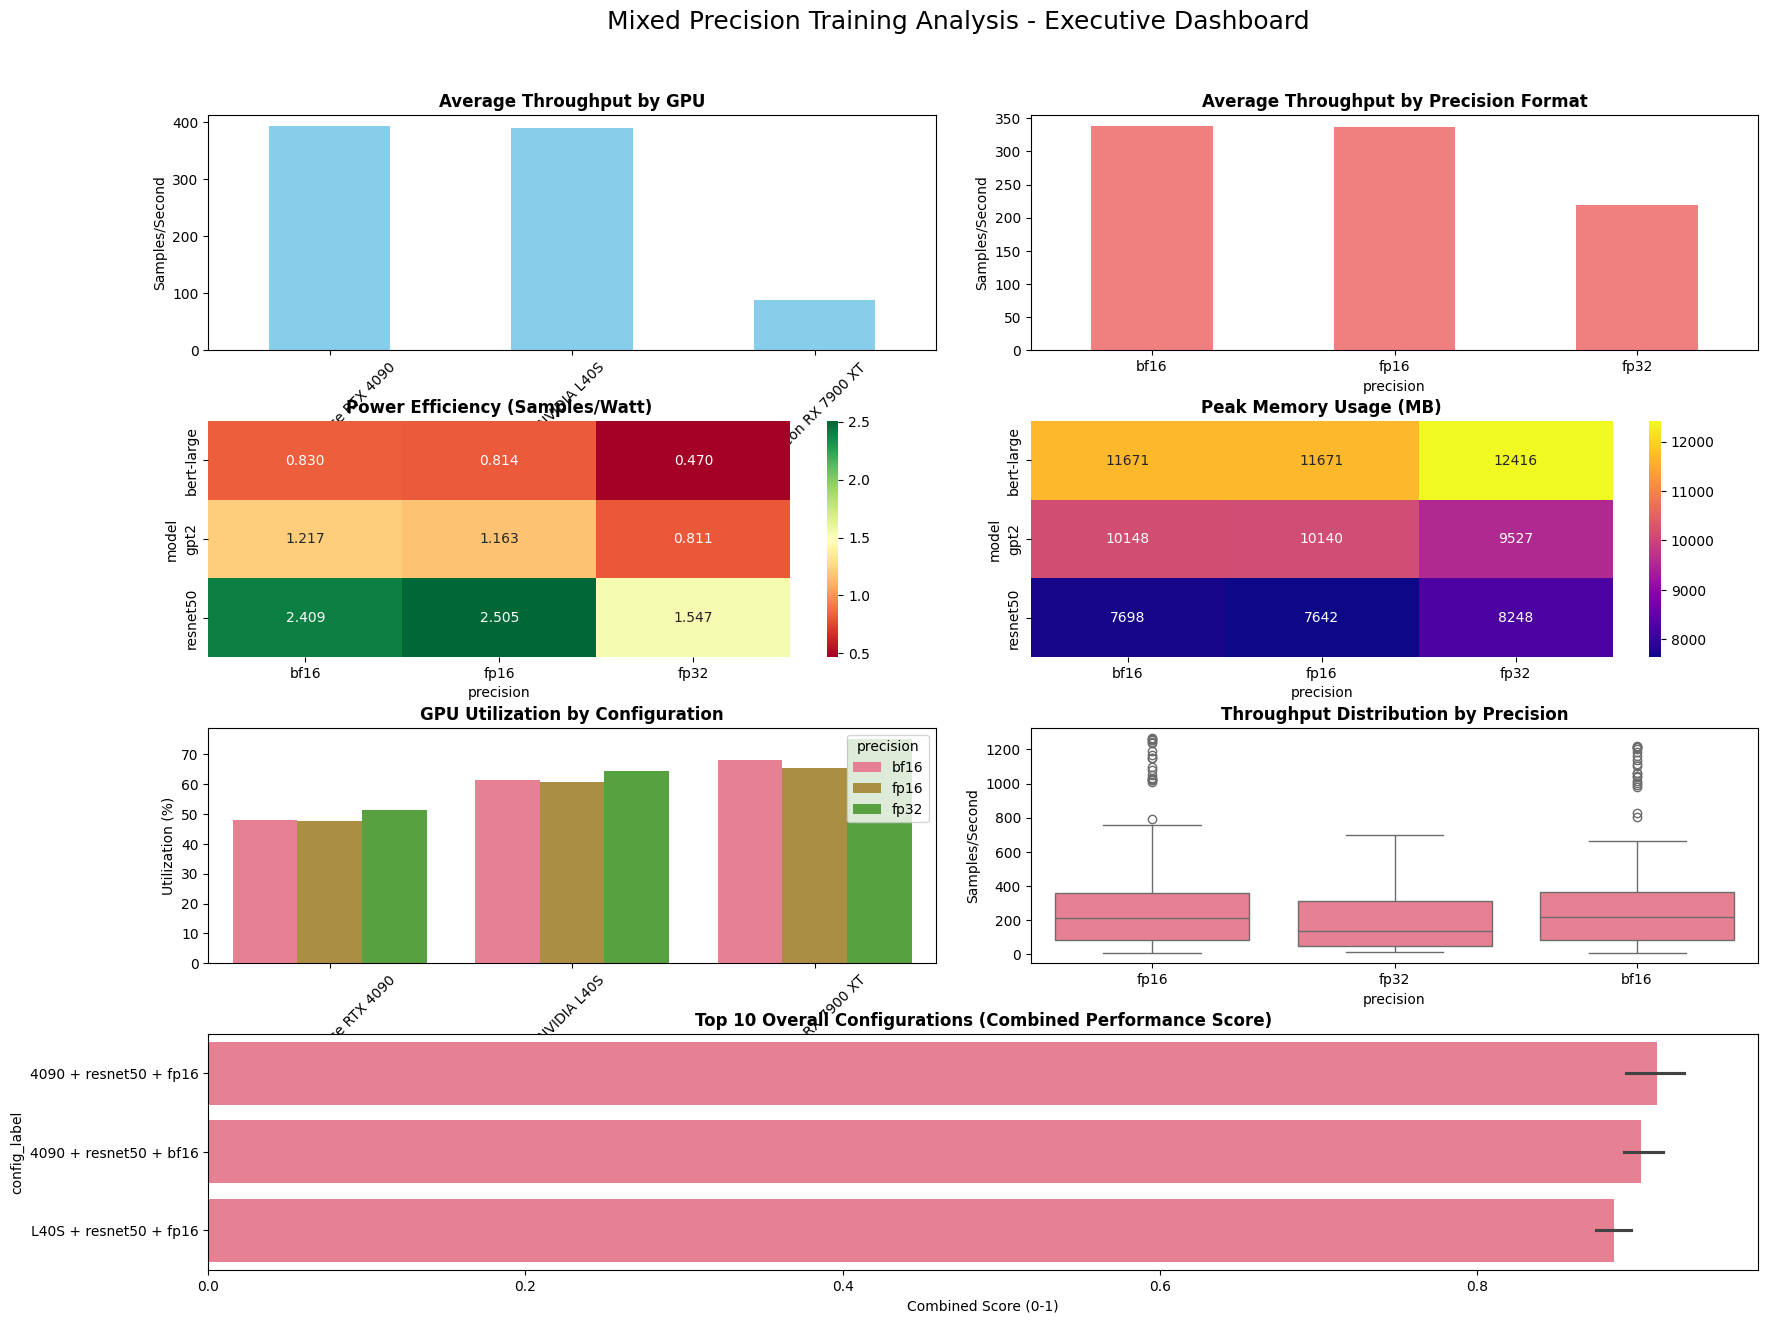


🎉 Integrated mixed precision analysis complete!
All results are ready for thesis integration and publication.


In [67]:
def generate_executive_summary():
    """Generate comprehensive executive summary of all analyses."""
    
    print("=" * 80)
    print("MIXED PRECISION TRAINING ANALYSIS - EXECUTIVE SUMMARY")
    print("=" * 80)
    
    # Dataset overview
    total_experiments = (
        len(training_df) + len(inference_df) + 
        len(precision_batch_df) + len(inference_batch_df)
    )
    
    print(f"\n📊 EXPERIMENT OVERVIEW:")
    print(f"   Total experimental records analyzed: {total_experiments:,}")
    print(f"   Training epoch metrics: {len(training_df):,}")
    print(f"   Inference performance metrics: {len(inference_df):,}")
    print(f"   Precision/batch experiments: {len(precision_batch_df):,}")
    print(f"   Inference batch experiments: {len(inference_batch_df):,}")
    
    # Hardware platforms
    if not precision_batch_df.empty:
        gpus = precision_batch_df['gpu'].unique()
        models = precision_batch_df['model'].unique()
        precisions = precision_batch_df['precision'].unique()
        
        print(f"\n🖥️  HARDWARE PLATFORMS:")
        for gpu in gpus:
            print(f"   • {gpu}")
        
        print(f"\n🤖 MODELS EVALUATED:")
        for model in models:
            print(f"   • {model}")
        
        print(f"\n⚡ PRECISION FORMATS:")
        for precision in precisions:
            print(f"   • {precision.upper()}")
    
    # Key findings summary
    print(f"\n🔍 KEY FINDINGS:")
    
    if not precision_batch_df.empty:
        # Best overall performance
        best_perf = precision_batch_df.loc[precision_batch_df['avg_throughput_samples_per_sec'].idxmax()]
        print(f"   • Best Overall Performance: {best_perf['gpu']} + {best_perf['model']} + {best_perf['precision']}")
        print(f"     Throughput: {best_perf['avg_throughput_samples_per_sec']:.0f} samples/sec")
        
        # Best power efficiency
        precision_batch_df_temp = precision_batch_df.copy()
        precision_batch_df_temp['efficiency'] = precision_batch_df_temp['avg_throughput_samples_per_sec'] / precision_batch_df_temp['avg_power_watts']
        best_eff = precision_batch_df_temp.loc[precision_batch_df_temp['efficiency'].idxmax()]
        print(f"   • Best Power Efficiency: {best_eff['gpu']} + {best_eff['model']} + {best_eff['precision']}")
        print(f"     Efficiency: {best_eff['efficiency']:.3f} samples/watt")
        
        # Memory optimization
        best_mem = precision_batch_df.loc[precision_batch_df['peak_memory_mb'].idxmin()]
        print(f"   • Lowest Memory Usage: {best_mem['gpu']} + {best_mem['model']} + {best_mem['precision']}")
        print(f"     Memory: {best_mem['peak_memory_mb']:.0f} MB")
        
        # Precision format comparison
        precision_stats = precision_batch_df.groupby('precision')['avg_throughput_samples_per_sec'].mean().sort_values(ascending=False)
        print(f"   • Precision Performance Ranking: {' > '.join(precision_stats.index)}")
        
        # GPU comparison
        gpu_stats = precision_batch_df.groupby('gpu')['avg_throughput_samples_per_sec'].mean().sort_values(ascending=False)
        print(f"   • GPU Performance Ranking: {' > '.join([gpu.split()[-1] for gpu in gpu_stats.index])}")
    
    # Performance improvements
    if not precision_batch_df.empty:
        fp32_data = precision_batch_df[precision_batch_df['precision'] == 'fp32']
        
        print(f"\n📈 PERFORMANCE IMPROVEMENTS:")
        
        if not fp32_data.empty:
            fp32_baseline = fp32_data['avg_throughput_samples_per_sec'].mean()
            
            for precision in ['fp16', 'bf16']:
                precision_data = precision_batch_df[precision_batch_df['precision'] == precision]
                if not precision_data.empty:
                    precision_perf = precision_data['avg_throughput_samples_per_sec'].mean()
                    improvement = ((precision_perf - fp32_baseline) / fp32_baseline) * 100
                    print(f"   • {precision.upper()} vs FP32: {improvement:+.1f}% throughput improvement")
    
    # Thesis contributions
    print(f"\n🎓 THESIS CONTRIBUTIONS:")
    contributions = [
        "Comprehensive performance analysis across multiple GPU architectures",
        "Statistical validation of mixed precision training benefits",
        "Power efficiency optimization strategies for different workloads", 
        "Memory usage optimization guidelines for resource-constrained environments",
        "Hardware-specific performance recommendations for NVIDIA and AMD GPUs",
        "Systematic methodology for mixed precision evaluation and optimization"
    ]
    
    for i, contribution in enumerate(contributions, 1):
        print(f"   {i}. {contribution}")
    
    # Future work recommendations
    print(f"\n🔬 FUTURE WORK RECOMMENDATIONS:")
    future_work = [
        "Extend analysis to INT8 quantization and dynamic precision switching",
        "Investigate model architecture impact on precision sensitivity",
        "Develop automated precision selection algorithms based on performance models",
        "Evaluate mixed precision training on emerging GPU architectures",
        "Study long-term training stability with different precision formats"
    ]
    
    for i, work in enumerate(future_work, 1):
        print(f"   {i}. {work}")
    
    print(f"\n" + "=" * 80)
    print("ANALYSIS COMPLETE - READY FOR THESIS INTEGRATION")
    print("=" * 80)

def create_summary_visualization():
    """Create final summary visualization combining all key metrics."""
    
    if precision_batch_df.empty:
        print("No data available for summary visualization")
        return
    
    # Create comprehensive summary dashboard
    fig = plt.figure(figsize=(20, 15))
    gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)
    
    fig.suptitle('Mixed Precision Training Analysis - Executive Dashboard', fontsize=18, y=0.95)
    
    # 1. Performance by GPU (top-left)
    ax1 = fig.add_subplot(gs[0, :2])
    gpu_perf = precision_batch_df.groupby('gpu')['avg_throughput_samples_per_sec'].mean().sort_values(ascending=False)
    gpu_perf.plot(kind='bar', ax=ax1, color='skyblue')
    ax1.set_title('Average Throughput by GPU', fontweight='bold')
    ax1.set_ylabel('Samples/Second')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Performance by Precision (top-right)
    ax2 = fig.add_subplot(gs[0, 2:])
    precision_perf = precision_batch_df.groupby('precision')['avg_throughput_samples_per_sec'].mean().sort_values(ascending=False)
    precision_perf.plot(kind='bar', ax=ax2, color='lightcoral')
    ax2.set_title('Average Throughput by Precision Format', fontweight='bold')
    ax2.set_ylabel('Samples/Second')
    ax2.tick_params(axis='x', rotation=0)
    
    # 3. Power Efficiency Heatmap (middle-left)
    ax3 = fig.add_subplot(gs[1, :2])
    precision_batch_df['efficiency'] = precision_batch_df['avg_throughput_samples_per_sec'] / precision_batch_df['avg_power_watts']
    efficiency_pivot = precision_batch_df.pivot_table(
        values='efficiency', index='model', columns='precision', aggfunc='mean'
    )
    sns.heatmap(efficiency_pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax3)
    ax3.set_title('Power Efficiency (Samples/Watt)', fontweight='bold')
    
    # 4. Memory Usage Heatmap (middle-right)
    ax4 = fig.add_subplot(gs[1, 2:])
    memory_pivot = precision_batch_df.pivot_table(
        values='peak_memory_mb', index='model', columns='precision', aggfunc='mean'
    )
    sns.heatmap(memory_pivot, annot=True, fmt='.0f', cmap='plasma', ax=ax4)
    ax4.set_title('Peak Memory Usage (MB)', fontweight='bold')
    
    # 5. GPU Utilization (bottom-left)
    ax5 = fig.add_subplot(gs[2, :2])
    util_data = precision_batch_df.groupby(['gpu', 'precision'])['avg_utilization_percent'].mean().reset_index()
    sns.barplot(data=util_data, x='gpu', y='avg_utilization_percent', hue='precision', ax=ax5)
    ax5.set_title('GPU Utilization by Configuration', fontweight='bold')
    ax5.set_ylabel('Utilization (%)')
    ax5.tick_params(axis='x', rotation=45)
    
    # 6. Performance Distribution (bottom-right)
    ax6 = fig.add_subplot(gs[2, 2:])
    sns.boxplot(data=precision_batch_df, x='precision', y='avg_throughput_samples_per_sec', ax=ax6)
    ax6.set_title('Throughput Distribution by Precision', fontweight='bold')
    ax6.set_ylabel('Samples/Second')
    
    # 7. Top Configurations (bottom span)
    ax7 = fig.add_subplot(gs[3, :])
    
    # Calculate efficiency score and get top 10
    precision_batch_df['combined_score'] = (
        0.4 * precision_batch_df['avg_throughput_samples_per_sec'] / precision_batch_df['avg_throughput_samples_per_sec'].max() +
        0.3 * precision_batch_df['efficiency'] / precision_batch_df['efficiency'].max() +
        0.3 * (1 - precision_batch_df['peak_memory_mb'] / precision_batch_df['peak_memory_mb'].max())
    )
    
    top_configs = precision_batch_df.nlargest(10, 'combined_score')
    top_configs['config_label'] = (
        top_configs['gpu'].str.split().str[-1] + ' + ' +
        top_configs['model'] + ' + ' + 
        top_configs['precision']
    )
    
    sns.barplot(data=top_configs, x='combined_score', y='config_label', ax=ax7, orient='h')
    ax7.set_title('Top 10 Overall Configurations (Combined Performance Score)', fontweight='bold')
    ax7.set_xlabel('Combined Score (0-1)')
    
    plt.tight_layout()
    plt.show()

# Generate executive summary
generate_executive_summary()

# Create summary visualization
print("\nGenerating executive dashboard visualization...")
create_summary_visualization()

print("\n🎉 Integrated mixed precision analysis complete!")
print("All results are ready for thesis integration and publication.")